I want to understand nsga2 article and implement the code from scratch

---
title: 'A Fast and Elitist Multiobjective Genetic Algorithm: NSGA-II'
source: Deb_NSGAII.pdf
pages: null
sections: 13
---

# A Fast and Elitist Multiobjective Genetic Algorithm: NSGA-II

Kalyanmoy Deb, Associate Member, IEEE, Amrit Pratap, Sameer Agarwal, and T. Meyarivan

Abstract—Multiobjective evolutionary algorithms (EAs) that use nondominated sorting and sharing have been criticized mainly for their: 1)  $O(MN^3)$  computational complexity (where M is the number of objectives and N is the population size); 2) nonelitism approach; and 3) the need for specifying a sharing parameter. In this paper, we suggest a nondominated sorting-based multiobjective EA (MOEA), called nondominated sorting genetic algorithm II (NSGA-II), which alleviates all the above three difficulties. Specifically, a fast nondominated sorting approach with  $O(MN^2)$  computational complexity is presented. Also, a selection operator is presented that creates a mating pool by combining the parent and offspring populations and selecting the best (with respect to fitness and spread) Nsolutions. Simulation results on difficult test problems show that the proposed NSGA-II, in most problems, is able to find much better spread of solutions and better convergence near the true Pareto-optimal front compared to Pareto-archived evolution strategy and strength-Pareto EA-two other elitist MOEAs that pay special attention to creating a diverse Pareto-optimal front. Moreover, we modify the definition of dominance in order to solve constrained multiobjective problems efficiently. Simulation results of the constrained NSGA-II on a number of test problems, including a five-objective seven-constraint nonlinear problem, are compared with another constrained multiobjective optimizer and much better performance of NSGA-II is observed.

Index Terms—Constraint handling, elitism, genetic algorithms, multicriterion decision making, multiobjective optimization, Pareto-optimal solutions.

### I. INTRODUCTION

THE PRESENCE of multiple objectives in a problem, in principle, gives rise to a set of optimal solutions (largely known as Pareto-optimal solutions), instead of a single optimal solution. In the absence of any further information, one of these Pareto-optimal solutions cannot be said to be better than the other. This demands a user to find as many Pareto-optimal solutions as possible. Classical optimization methods (including the multicriterion decision-making methods) suggest converting the multiobjective optimization problem to a single-objective optimization problem by emphasizing one particular Pareto-optimal solution at a time. When such a method is to be used for finding multiple solutions, it has to be applied many times, hopefully finding a different solution at each simulation run.

Over the past decade, a number of multiobjective evolutionary algorithms (MOEAs) have been suggested [1], [7], [13],

Manuscript received August 18, 2000; revised February 5, 2001 and September 7, 2001. The work of K. Deb was supported by the Ministry of Human Resources and Development, India, under the Research and Development Scheme.

The authors are with the Kanpur Genetic Algorithms Laboratory, Indian Institute of Technology, Kanpur PIN 208 016, India (e-mail: deb@iitk.ac.in). Publisher Item Identifier S 1089-778X(02)04101-2.

[20], [26]. The primary reason for this is their ability to find multiple Pareto-optimal solutions in one single simulation run. Since evolutionary algorithms (EAs) work with a population of solutions, a simple EA can be extended to maintain a diverse set of solutions. With an emphasis for moving toward the true Pareto-optimal region, an EA can be used to find multiple Pareto-optimal solutions in one single simulation run.

The nondominated sorting genetic algorithm (NSGA) proposed in [20] was one of the first such EAs. Over the years, the main criticisms of the NSGA approach have been as follows.

- 1) High computational complexity of nondominated sorting: The currently-used nondominated sorting algorithm has a computational complexity of  $O(MN^3)$  (where M is the number of objectives and N is the population size). This makes NSGA computationally expensive for large population sizes. This large complexity arises because of the complexity involved in the nondominated sorting procedure in every generation.
- 2) Lack of elitism: Recent results [25], [18] show that elitism can speed up the performance of the GA significantly, which also can help preventing the loss of good solutions once they are found.
- 3) Need for specifying the sharing parameter  $\sigma_{\rm share}$ : Traditional mechanisms of ensuring diversity in a population so as to get a wide variety of equivalent solutions have relied mostly on the concept of sharing. The main problem with sharing is that it requires the specification of a sharing parameter ( $\sigma_{\rm share}$ ). Though there has been some work on dynamic sizing of the sharing parameter [10], a parameter-less diversity-preservation mechanism is desirable.

In this paper, we address all of these issues and propose an improved version of NSGA, which we call NSGA-II. From the simulation results on a number of difficult test problems, we find that NSGA-II outperforms two other contemporary MOEAs: Pareto-archived evolution strategy (PAES) [14] and strength-Pareto EA (SPEA) [24] in terms of finding a diverse set of solutions and in converging near the true Pareto-optimal set.

Constrained multiobjective optimization is important from the point of view of practical problem solving, but not much attention has been paid so far in this respect among the EA researchers. In this paper, we suggest a simple constraint-handling strategy with NSGA-II that suits well for any EA. On four problems chosen from the literature, NSGA-II has been compared with another recently suggested constraint-handling strategy. These results encourage the application of NSGA-II to more complex and real-world multiobjective optimization problems.

In the remainder of the paper, we briefly mention a number of existing elitist MOEAs in Section II. Thereafter, in Section III,

we describe the proposed NSGA-II algorithm in details. Section IV presents simulation results of NSGA-II and compares them with two other elitist MOEAs (PAES and SPEA). In Section V, we highlight the issue of parameter interactions, a matter that is important in evolutionary computation research. The next section extends NSGA-II for handling constraints and compares the results with another recently proposed constraint-handling method. Finally, we outline the conclusions of this paper.

# II. ELITIST MULTIOBJECTIVE EVOLUTIONARY ALGORITHMS

During 1993–1995, a number of different EAs were suggested to solve multiobjective optimization problems. Of them, Fonseca and Fleming's MOGA [7], Srinivas and Deb's NSGA [20], and Horn *et al.*'s NPGA [13] enjoyed more attention. These algorithms demonstrated the necessary additional operators for converting a simple EA to a MOEA. Two common features on all three operators were the following: i) assigning fitness to population members based on nondominated sorting and ii) preserving diversity among solutions of the same nondominated front. Although they have been shown to find multiple nondominated solutions on many test problems and a number of engineering design problems, researchers realized the need of introducing more useful operators (which have been found useful in single-objective EA's) so as to solve multiobjective optimization problems better. Particularly, the interest has been to introduce elitism to enhance the convergence properties of a MOEA. Reference [25] showed that elitism helps in achieving better convergence in MOEAs. Among the existing elitist MOEAs, Zitzler and Thiele's SPEA [26], Knowles and Corne's Pareto-archived PAES [14], and Rudolph's elitist GA [18] are well studied. We describe these approaches in brief. For details, readers are encouraged to refer to the original studies.

Zitzler and Thiele [26] suggested an elitist multicriterion EA with the concept of nondomination in their SPEA. They suggested maintaining an external population at every generation storing all nondominated solutions discovered so far beginning from the initial population. This external population participates in all genetic operations. At each generation, a combined population with the external and the current population is first constructed. All nondominated solutions in the combined population are assigned a fitness based on the number of solutions they dominate and dominated solutions are assigned fitness worse than the worst fitness of any nondominated solution. This assignment of fitness makes sure that the search is directed toward the nondominated solutions. A deterministic clustering technique is used to ensure diversity among nondominated solutions. Although the implementation suggested in [26] is , with proper bookkeeping the complexity of SPEA can be reduced to .

Knowles and Corne [14] suggested a simple MOEA using a single-parent single-offspring EA similar to (1 1)-evolution strategy. Instead of using real parameters, binary strings were used and bitwise mutations were employed to create offsprings. In their PAES, with one parent and one offspring, the offspring is compared with respect to the parent. If the offspring dominates the parent, the offspring is accepted as the next parent and the iteration continues. On the other hand, if the parent dominates the offspring, the offspring is discarded and a new mutated solution (a new offspring) is found. However, if the offspring and the parent do not dominate each other, the choice between the offspring and the parent is made by comparing them with an archive of best solutions found so far. The offspring is compared with the archive to check if it dominates any member of the archive. If it does, the offspring is accepted as the new parent and all the dominated solutions are eliminated from the archive. If the offspring does not dominate any member of the archive, both parent and offspring are checked for their *nearness* with the solutions of the archive. If the offspring resides in a least crowded region in the objective space among the members of the archive, it is accepted as a parent and a copy of added to the archive. Crowding is maintained by dividing the entire search space deterministically in subspaces, where is the depth parameter and is the number of decision variables, and by updating the subspaces dynamically. Investigators have calculated the worst case complexity of PAES for evaluations as , where is the archive length. Since the archive size is usually chosen proportional to the population size , the overall complexity of the algorithm is .

Rudolph [18] suggested, but did not simulate, a simple elitist MOEA based on a systematic comparison of individuals from parent and offspring populations. The nondominated solutions of the offspring population are compared with that of parent solutions to form an overall nondominated set of solutions, which becomes the parent population of the next iteration. If the size of this set is not greater than the desired population size, other individuals from the offspring population are included. With this strategy, he proved the convergence of this algorithm to the Pareto-optimal front. Although this is an important achievement in its own right, the algorithm lacks motivation for the second task of maintaining diversity of Pareto-optimal solutions. An explicit diversity-preserving mechanism must be added to make it more practical. Since the determinism of the first nondominated front is , the overall complexity of Rudolph's algorithm is also .

In the following, we present the proposed nondominated sorting GA approach, which uses a fast nondominated sorting procedure, an elitist-preserving approach, and a parameterless niching operator.

# III. ELITIST NONDOMINATED SORTING GENETIC ALGORITHM



# *A. Fast Nondominated Sorting Approach*

For the sake of clarity, we first describe a naive and slow procedure of sorting a population into different nondomination levels. Thereafter, we describe a fast approach.

In a naive approach, in order to identify solutions of the first nondominated front in a population of size , each solution can be compared with every other solution in the population to find if it is dominated. This requires comparisons for each solution, where is the number of objectives. When this process is continued to find all members of the first nondominated level in the population, the total complexity is . At this stage, all individuals in the first nondominated front are found. In order to find the individuals in the next nondominated front, the solutions of the first front are discounted temporarily and the above procedure is repeated. In the worst case, the task of finding the second front also requires computations, particularly when number of solutions belong to the second and higher nondominated levels. This argument is true for finding third and higher levels of nondomination. Thus, the worst case is when there are fronts and there exists only one solution in each front. This requires an overall computations. Note that storage is required for this procedure. In the following paragraph and equation shown at the bottom of the page, we describe a fast nondominated sorting approach which will require computations.

First, for each solution we calculate two entities: 1) domination count , the number of solutions which dominate the solution , and 2) , a set of solutions that the solution dominates. This requires comparisons.

All solutions in the first nondominated front will have their domination count as zero. Now, for each solution with , we visit each member ( ) of its set and reduce its domination count by one. In doing so, if for any member the domination count becomes zero, we put it in a separate list . These members belong to the second nondominated front. Now, the above procedure is continued with each member of and the third front is identified. This process continues until all fronts are identified.

For each solution in the second or higher level of nondomination, the domination count can be at most . Thus, each solution will be visited at most times before its domination count becomes zero. At this point, the solution is assigned a nondomination level and will never be visited again. Since there are at most such solutions, the total complexity is . Thus, the overall complexity of the procedure is . Another way to calculate this complexity is to realize that the body of the first inner loop (for each ) is executed exactly times as each individual can be the member of at most one front and the second inner loop (for each ) can be executed at maximum times for each individual [each individual dominates individuals at maximum and each domination check requires at most comparisons] results in the overall computations. It is important to note that although the time complexity has reduced to , the storage requirement has increased to .

# *B. Diversity Preservation*

We mentioned earlier that, along with convergence to the Pareto-optimal set, it is also desired that an EA maintains a good spread of solutions in the obtained set of solutions. The original NSGA used the well-known sharing function approach, which has been found to maintain sustainable diversity in a population with appropriate setting of its associated parameters. The sharing function method involves a sharing parameter , which sets the extent of sharing desired in a problem. This parameter is related to the distance metric chosen to calculate the proximity measure between two population members. The parameter denotes the largest value of that distance metric within which any two solutions share each other's fitness. This parameter is usually set by the user, although there exist some guidelines [4]. There are two difficulties with this sharing function approach.

1) The performance of the sharing function method in maintaining a spread of solutions depends largely on the chosen value.

```
- - -
```

```
for each
 for each
   if then If dominates
   else if then
 if then belongs to the first front
while
 for each
   for each
```

Add to the set of solutions dominated by

Increment the domination counter of

Initialize the front counter

Used to store the members of the next front

if then belongs to the next front

![](Deb_NSGAII_images\_page_3_Figure_2.jpeg)

Fig. 1. Crowding-distance calculation. Points marked in filled circles are solutions of the same nondominated front.

2) Since each solution must be compared with all other solutions in the population, the overall complexity of the sharing function approach is .

In the proposed NSGA-II, we replace the sharing function approach with a crowded-comparison approach that eliminates both the above difficulties to some extent. The new approach does not require *any* user-defined parameter for maintaining diversity among population members. Also, the suggested approach has a better computational complexity. To describe this approach, we first define a density-estimation metric and then present the crowded-comparison operator.

*1) Density Estimation:* To get an estimate of the density of solutions surrounding a particular solution in the population, we calculate the average distance of two points on either side of this point along each of the objectives. This quantity serves as an estimate of the perimeter of the cuboid formed by using the nearest neighbors as the vertices (call this the *crowding distance*). In Fig. 1, the crowding distance of the th solution in its front (marked with solid circles) is the average side length of the cuboid (shown with a dashed box).

The crowding-distance computation requires sorting the population according to each objective function value in ascending order of magnitude. Thereafter, for each objective function, the boundary solutions (solutions with smallest and largest function values) are assigned an infinite distance value. All other intermediate solutions are assigned a distance value equal to the absolute normalized difference in the function values of two adjacent solutions. This calculation is continued with other objective functions. The overall crowding-distance value is calculated as the sum of individual distance values corresponding to each objective. Each objective function is normalized before calculating the crowding distance. The algorithm as shown at the bottom of the page outlines the crowding-distance computation procedure of all solutions in an nondominated set .

Here, refers to the th objective function value of the th individual in the set and the parameters and are the maximum and minimum values of the th objective function. The complexity of this procedure is governed by the sorting algorithm. Since independent sortings of at most solutions (when all population members are in one front ) are involved, the above algorithm has computational complexity.

After all population members in the set are assigned a distance metric, we can compare two solutions for their extent of proximity with other solutions. A solution with a smaller value of this distance measure is, in some sense, more crowded by other solutions. This is exactly what we compare in the proposed crowded-comparison operator, described below. Although Fig. 1 illustrates the crowding-distance computation for two objectives, the procedure is applicable to more than two objectives as well.

- *2) Crowded-Comparison Operator:* The crowded-comparison operator ( ) guides the selection process at the various stages of the algorithm toward a uniformly spread-out Paretooptimal front. Assume that every individual in the population has two attributes:
  - 1) nondomination rank ( );
  - 2) crowding distance ( ).

We now define a partial order as

$$i \prec_n j$$
 if  $(i_{\text{rank}} < j_{\text{rank}})$   
or  $((i_{\text{rank}} = j_{\text{rank}})$   
and  $(i_{\text{distance}} > j_{\text{distance}}))$ 

That is, between two solutions with differing nondomination ranks, we prefer the solution with the lower (better) rank. Otherwise, if both solutions belong to the same front, then we prefer the solution that is located in a lesser crowded region.

With these three new innovations—a fast nondominated sorting procedure, a fast crowded distance estimation procedure, and a simple crowded comparison operator, we are now ready to describe the NSGA-II algorithm.

### *C. Main Loop*

Initially, a random parent population is created. The population is sorted based on the nondomination. Each solution is assigned a fitness (or rank) equal to its nondomination level (1 is the best level, 2 is the next-best level, and so on). Thus, minimization of fitness is assumed. At first, the usual binary tournament selection, recombination, and mutation operators are used to create a offspring population of size . Since elitism

```
- -
                                  number of solutions in
for each set initialize distance
for each objective
    sort sort using each objective value
                                  so that boundary points are always selected
 for to for all other points
```

is introduced by comparing current population with previously found best nondominated solutions, the procedure is different after the initial generation. We first describe the th generation of the proposed algorithm as shown at the bottom of the page.

The step-by-step procedure shows that NSGA-II algorithm is simple and straightforward. First, a combined population is formed. The population is of size . Then, the population is sorted according to nondomination. Since all previous and current population members are included in , elitism is ensured. Now, solutions belonging to the best nondominated set are of best solutions in the combined population and must be emphasized more than any other solution in the combined population. If the size of is smaller then , we definitely choose all members of the set for the new population . The remaining members of the population are chosen from subsequent nondominated fronts in the order of their ranking. Thus, solutions from the set are chosen next, followed by solutions from the set , and so on. This procedure is continued until no more sets can be accommodated. Say that the set is the last nondominated set beyond which no other set can be accommodated. In general, the count of solutions in all sets from to would be larger than the population size. To choose exactly population members, we sort the solutions of the *last* front using the crowded-comparison operator in descending order and choose the best solutions needed to fill all population slots. The NSGA-II procedure is also shown in Fig. 2. The new population of size is now used for selection, crossover, and mutation to create a new population of size . It is important to note that we use a binary tournament selection operator but the selection criterion is now based on the crowded-comparison operator . Since this operator requires both the rank and crowded distance of each solution in the population, we calculate these quantities while forming the population , as shown in the above algorithm.

Consider the complexity of one iteration of the entire algorithm. The basic operations and their worst-case complexities are as follows:

- 1) nondominated sorting is ;
- 2) crowding-distance assignment is ;
- 3) sorting on is .

The overall complexity of the algorithm is , which is governed by the nondominated sorting part of the algorithm. If

![](Deb_NSGAII_images\_page_4_Figure_9.jpeg)

Fig. 2. NSGA-II procedure.

performed carefully, the complete population of size need not be sorted according to nondomination. As soon as the sorting procedure has found enough number of fronts to have members in , there is no reason to continue with the sorting procedure.

The diversity among nondominated solutions is introduced by using the crowding comparison procedure, which is used in the tournament selection and during the population reduction phase. Since solutions compete with their crowding-distance (a measure of density of solutions in the neighborhood), no extra niching parameter (such as needed in the NSGA) is required. Although the crowding distance is calculated in the objective function space, it can also be implemented in the parameter space, if so desired [3]. However, in all simulations performed in this study, we have used the objective-function space niching.

### IV. SIMULATION RESULTS

In this section, we first describe the test problems used to compare the performance of NSGA-II with PAES and SPEA. For PAES and SPEA, we have identical parameter settings as suggested in the original studies. For NSGA-II, we have chosen a reasonable set of values and have not made any effort in finding the best parameter setting. We leave this task for a future study.

```
- - - all nondominated fronts of
     and
until until the parent population is filled
      - - calculate crowding-distance in
Sort sort in descending order using
```

include th nondominated front in the parent pop check the next front for inclusion choose the first elements of - - use selection, crossover and mutation to create a new population

combine parent and offspring population

increment the generation counter

TABLE I TEST PROBLEMS USED IN THIS STUDY

| Problem | n  | Variable           | Objective                                                                                                                                                                                               | Optimal                         | Comments     |
|---------|----|--------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|---------------------------------|--------------|
|         |    | bounds             | functions                                                                                                                                                                                               | solutions                       |              |
| SCH     | 1  | $[-10^3, 10^3]$    | $f_1(x) = x^2$                                                                                                                                                                                          | $x \in [0, 2]$                  | convex       |
|         |    |                    | $f_2(x) = (x-2)^2$                                                                                                                                                                                      |                                 |              |
|         |    |                    | ( , , , , , , , , , , , , , , , , , , ,                                                                                                                                                                 |                                 |              |
| FON     | 3  | [-4,4]             | $f_1(\mathbf{x}) = 1 - \exp\left(-\sum_{i=1}^3 \left(x_i - \frac{1}{\sqrt{3}}\right)^2\right)$                                                                                                          | $x_1 = x_2 = x_3$               | nonconvex    |
|         |    |                    | $\rangle = \frac{1}{2} \langle \frac{1}{2} \rangle$                                                                                                                                                     | - [ 4 / [ 4 / [ 6] ]            |              |
|         |    |                    | $f_2(\mathbf{x}) = 1 - \exp\left(-\sum_{i=1}^{3} \left(x_i + \frac{1}{\sqrt{3}}\right)^2\right)$                                                                                                        | $\in [-1/\sqrt{3}, 1/\sqrt{3}]$ |              |
| POL     | 2  | $[-\pi,\pi]$       | $f_1(\mathbf{x}) = \left[1 + (A_1 - B_1)^2 + (A_2 - B_2)^2\right]$                                                                                                                                      | (refer [1])                     | nonconvex,   |
|         |    | . , ,              | $f_2(\mathbf{x}) = [(x_1 + 3)^2 + (x_2 + 1)^2]$                                                                                                                                                         |                                 | disconnected |
|         |    |                    | $A_1 = 0.5\sin 1 - 2\cos 1 + \sin 2 - 1.5\cos 2$                                                                                                                                                        |                                 |              |
|         |    |                    | $A_2 = 1.5\sin 1 - \cos 1 + 2\sin 2 - 0.5\cos 2$                                                                                                                                                        |                                 |              |
|         |    |                    | $B_1 = 0.5\sin x_1 - 2\cos x_1 + \sin x_2 - 1.5\cos x_2$                                                                                                                                                |                                 |              |
|         |    |                    | $B_2 = 1.5\sin x_1 - \cos x_1 + 2\sin x_2 - 0.5\cos x_2$                                                                                                                                                |                                 |              |
| KUR     | 3  | [-5, 5]            | $f_1(\mathbf{x}) = \sum_{i=1}^{n-1} \left( -10 \exp\left(-0.2\sqrt{x_i^2 + x_{i+1}^2}\right) \right)$                                                                                                   | (refer [1])                     | nonconvex    |
| KOK     | "  | [-0,0]             | $\begin{cases} f_1(\mathbf{x}) = \sum_{i=1}^{n} \left(  x_i ^{0.8} + 5\sin x_i^3 \right) \\ f_2(\mathbf{x}) = \sum_{i=1}^{n} \left(  x_i ^{0.8} + 5\sin x_i^3 \right) \end{cases}$                      | (refer [2])                     | nonconven    |
|         |    |                    | $\int_{2} f_2(\mathbf{x}) = \sum_{i=1} \left(  x_i ^{3/3} + 5 \sin x_i^* \right)$                                                                                                                       |                                 |              |
| ZDT1    | 30 | [0, 1]             | $f_1(\mathbf{x}) = x_1$                                                                                                                                                                                 | $x_1 \in [0,1]$                 | convex       |
|         |    |                    | $f_2(\mathbf{x}) = g(\mathbf{x}) \left[ 1 - \sqrt{x_1/g(\mathbf{x})} \right]$                                                                                                                           | $x_i = 0,$                      |              |
|         |    |                    | $g(\mathbf{x}) = 1 + 9\left(\sum_{i=2}^{n} x_i\right) / (n-1)$                                                                                                                                          | $i=2,\ldots,n$                  |              |
|         |    | ro 41              | , , , , , , , , , , , , , , , , , , , ,                                                                                                                                                                 | - [0 1]                         |              |
| ZDT2    | 30 | [0,1]              | $f_1(\mathbf{x}) = x_1$                                                                                                                                                                                 | $x_1 \in [0,1]$                 | nonconvex    |
|         |    |                    | $f_2(\mathbf{x}) = g(\mathbf{x}) \left[ 1 - (x_1/g(\mathbf{x}))^2 \right]$                                                                                                                              | $x_i = 0,$                      |              |
|         |    |                    | $g(\mathbf{x}) = 1 + 9\left(\sum_{i=2}^{n} x_i\right) / (n-1)$                                                                                                                                          | $i=2,\ldots,n$                  |              |
| ZDT3    | 30 | [0, 1]             | $f_1(\mathbf{x}) = x_1$                                                                                                                                                                                 | $x_1 \in [0, 1]$                | convex,      |
|         | •• | [-,-]              | $f_2(\mathbf{x}) = g(\mathbf{x}) \left[ 1 - \sqrt{x_1/g(\mathbf{x})} - \frac{x_1}{g(\mathbf{x})} \sin(10\pi x_1) \right]$                                                                               | $x_i = 0$                       | disconnected |
|         |    |                    | $\begin{cases} f_2(\mathbf{x}) = g(\mathbf{x}) \left[ 1 & \sqrt{x} f_j(\mathbf{x}) & g(\mathbf{x}) \text{ sin}(10x^{2}f_j) \\ g(\mathbf{x}) = 1 + 9\left(\sum_{i=2}^{n} x_i\right) / (n-1) \end{cases}$ | $i=2,\ldots,n$                  |              |
|         |    |                    | $\frac{g(\mathbf{x}) - 1 + g(\mathbf{x}_{i=2} x_i) / (n-1)}{\cdot}$                                                                                                                                     | , ´ ´                           |              |
| ZDT4    | 10 | ,                  | $f_1(\mathbf{x}) = x_1$                                                                                                                                                                                 | $x_1 \in [0,1]$                 | nonconvex    |
|         |    | $x_i \in [-5, 5],$ | $f_2(\mathbf{x}) = g(\mathbf{x}) \left[ 1 - \sqrt{x_1/g(\mathbf{x})} \right]$                                                                                                                           | $x_i = 0,$                      |              |
|         |    | $i=2,\ldots,n$     | $g(\mathbf{x}) = 1 + 10(n-1) + \sum_{i=2}^{n-1} \left[ x_i^2 - 10\cos(4\pi x_i) \right]$                                                                                                                | $i=2,\ldots,n$                  |              |
| ZDT6    | 10 | [0, 1]             | $f_1(\mathbf{x}) = 1 - \exp(-4x_1)\sin^6(6\pi x_1)$                                                                                                                                                     | $x_1 \in [0, 1]$                | nonconvex,   |
|         |    |                    | $f_2(\mathbf{x}) = g(\mathbf{x}) \left[ 1 - (f_1(\mathbf{x})/g(\mathbf{x}))^2 \right]$                                                                                                                  | $x_i = 0$                       | nonuniformly |
|         |    |                    | $g(\mathbf{x}) = g(\mathbf{x}) \left[ \frac{1}{2} \left( \frac{1}{2} (1/2) + \frac{1}{2} (1/2) \right) \right]^{0.25}$                                                                                  | $i=2,\ldots,n$                  | spaced       |
|         | L  | l                  | $g(\mathbf{x}) = 1 + 9[(\sum_{i=2} x_i)/(n-1)]$                                                                                                                                                         | $t-2,\ldots,n$                  | spaceu       |

All objective functions are to be minimized.

## *A. Test Problems*

We first describe the test problems used to compare different MOEAs. Test problems are chosen from a number of significant past studies in this area. Veldhuizen [22] cited a number of test problems that have been used in the past. Of them, we choose four problems: Schaffer's study (SCH) [19], Fonseca and Fleming's study (FON) [10], Poloni's study (POL) [16], and Kursawe's study (KUR) [15]. In 1999, the first author suggested a systematic way of developing test problems for multiobjective optimization [3]. Zitzler *et al.* [25] followed those guidelines and suggested six test problems. We choose five of those six problems here and call them ZDT1, ZDT2, ZDT3, ZDT4, and ZDT6. All problems have two objective functions. None of these problems have any constraint. We describe these problems in Table I. The table also shows the number of variables, their bounds, the Pareto-optimal solutions, and the nature of the Pareto-optimal front for each problem.

All approaches are run for a maximum of 25 000 function evaluations. We use the single-point crossover and bitwise mutation for binary-coded GAs and the simulated binary crossover (SBX) operator and polynomial mutation [6] for real-coded GAs. The crossover probability of and a mutation probability of or (where is the number of decision variables for real-coded GAs and is the string length for binary-coded GAs) are used. For real-coded NSGA-II, we use distribution indexes [6] for crossover and mutation operators as and , respectively. The population obtained at the end of 250 generations (the population after elite-preserving operator is applied) is used to calculate a couple of performance metrics, which we discuss in the next section. For PAES, we use a depth value equal to four and an archive size of 100. We use all population members of the archive obtained at the end of 25 000 iterations to calculate the performance metrics. For SPEA, we use a population of size 80 and an external population of size 20 (this 4 : 1 ratio is suggested by the developers of SPEA to maintain an adequate selection pressure for the elite solutions), so that overall population size becomes 100. SPEA is also run until 25 000 function evaluations are done. For SPEA, we use the

![](Deb_NSGAII_images\_page_6_Figure_2.jpeg)

Fig. 3. Distance metric .

nondominated solutions of the combined GA and external populations at the final generation to calculate the performance metrics used in this study. For PAES, SPEA, and binary-coded NSGA-II, we have used 30 bits to code each decision variable.

### *B. Performance Measures*

Unlike in single-objective optimization, there are two goals in a multiobjective optimization: 1) convergence to the Pareto-optimal set and 2) maintenance of diversity in solutions of the Pareto-optimal set. These two tasks cannot be measured adequately with one performance metric. Many performance metrics have been suggested [1], [8], [24]. Here, we define two performance metrics that are more direct in evaluating each of the above two goals in a solution set obtained by a multiobjective optimization algorithm.

The first metric measures the extent of convergence to a known set of Pareto-optimal solutions. Since multiobjective algorithms would be tested on problems having a known set of Pareto-optimal solutions, the calculation of this metric is possible. We realize, however, that such a metric cannot be used for any arbitrary problem. First, we find a set of uniformly spaced solutions from the true Pareto-optimal front in the objective space. For each solution obtained with an algorithm, we compute the minimum Euclidean distance of it from chosen solutions on the Pareto-optimal front. The average of these distances is used as the first metric (the convergence metric). Fig. 3 shows the calculation procedure of this metric. The shaded region is the feasible search region and the solid curved lines specify the Pareto-optimal solutions. Solutions with open circles are chosen solutions on the Pareto-optimal front for the calculation of the convergence metric and solutions marked with dark circles are solutions obtained by an algorithm. The smaller the value of this metric, the better the convergence toward the Pareto-optimal front. When all obtained solutions lie exactly on chosen solutions, this metric takes a value of zero. In all simulations performed here, we present the average and variance of this metric calculated for solution sets obtained in multiple runs.

Even when all solutions converge to the Pareto-optimal front, the above convergence metric does not have a value of zero. The metric will yield zero only when each obtained solution lies exactly on each of the chosen solutions. Although this metric alone

![](Deb_NSGAII_images\_page_6_Figure_9.jpeg)

Fig. 4. Diversity metric .

can provide some information about the spread in obtained solutions, we define an different metric to measure the spread in solutions obtained by an algorithm directly. The second metric measures the extent of spread achieved among the obtained solutions. Here, we are interested in getting a set of solutions that spans the entire Pareto-optimal region. We calculate the Euclidean distance between consecutive solutions in the obtained nondominated set of solutions. We calculate the average of these distances. Thereafter, from the obtained set of nondominated solutions, we first calculate the *extreme* solutions (in the objective space) by fitting a curve parallel to that of the true Pareto-optimal front. Then, we use the following metric to calculate the nonuniformity in the distribution:

$$\Delta = \frac{d_f + d_l + \sum_{i=1}^{N-1} |d_i - \overline{d}|}{d_f + d_l + (N-1)\overline{d}}.$$
 (1)

Here, the parameters and are the Euclidean distances between the extreme solutions and the boundary solutions of the obtained nondominated set, as depicted in Fig. 4. The figure illustrates all distances mentioned in the above equation. The parameter is the average of all distances , , assuming that there are solutions on the best nondominated front. With solutions, there are consecutive distances. The denominator is the value of the numerator for the case when all solutions lie on one solution. It is interesting to note that this is not the worst case spread of solutions possible. We can have a scenario in which there is a large variance in . In such scenarios, the metric may be greater than one. Thus, the maximum value of the above metric can be greater than one. However, a good distribution would make all distances equal to and would make (with existence of extreme solutions in the nondominated set). Thus, for the most widely and uniformly spreadout set of nondominated solutions, the numerator of would be zero, making the metric to take a value zero. For any other distribution, the value of the metric would be greater than zero. For two distributions having identical values of and , the metric takes a higher value with worse distributions of solutions within the extreme solutions. Note that the above diversity metric can be used on any nondominated set of solutions, including one that is not the Pareto-optimal set. Using

|              |          |          |          |          |          | _        |          |          |          |
|--------------|----------|----------|----------|----------|----------|----------|----------|----------|----------|
| Algorithm    | SCH      | FON      | POL      | KUR      | ZDT1     | ZDT2     | ZDT3     | ZDT4     | ZDT6     |
| NSGA-II      | 0.003391 | 0.001931 | 0.015553 | 0.028964 | 0.033482 | 0.072391 | 0.114500 | 0.513053 | 0.296564 |
| Real-coded   | 0        | 0        | 0.000001 | 0.000018 | 0.004750 | 0.031689 | 0.007940 | 0.118460 | 0.013135 |
| NSGA-II      | 0.002833 | 0.002571 | 0.017029 | 0.028951 | 0.000894 | 0.000824 | 0.043411 | 3.227636 | 7.806798 |
| Binary-coded | 0.000001 | 0        | 0.000003 | 0.000016 | 0        | 0        | 0.000042 | 7.30763  | 0.001667 |
| SPEA         | 0.003403 | 0.125692 | 0.037812 | 0.045617 | 0.001799 | 0.001339 | 0.047517 | 7.340299 | 0.221138 |
| JELA         | 0        | 0.000038 | 0.000088 | 0.00005  | 0.000001 | 0        | 0.000047 | 6.572516 | 0.000449 |
| PAES         | 0.001313 | 0.151263 | 0.030864 | 0.057323 | 0.082085 | 0.126276 | 0.023872 | 0.854816 | 0.085469 |
|              | 0.000003 | 0.000905 | 0.000431 | 0.011989 | 0.008679 | 0.036877 | 0.00001  | 0.527238 | 0.006664 |

TABLE II MEAN (FIRST ROWS) AND VARIANCE (SECOND ROWS) OF THE CONVERGENCE METRIC

TABLE III MEAN (FIRST ROWS) AND VARIANCE (SECOND ROWS) OF THE DIVERSITY METRIC

| Algorithm    | SCH      | FON      | POL      | KUR      | ZDT1     | ZDT2     | ZDT3     | ZDT4     | ZDT6     |
|--------------|----------|----------|----------|----------|----------|----------|----------|----------|----------|
| NSGA2R       | 0.477899 | 0.378065 | 0.452150 | 0.411477 | 0.390307 | 0.430776 | 0.738540 | 0.702612 | 0.668025 |
| Real-coded   | 0.003471 | 0.000639 | 0.002868 | 0.000992 | 0.001876 | 0.004721 | 0.019706 | 0.064648 | 0.009923 |
| NSGA-II      | 0.449265 | 0.395131 | 0.503721 | 0.442195 | 0.463292 | 0.435112 | 0.575606 | 0.479475 | 0.644477 |
| Binary-coded | 0.002062 | 0.001314 | 0.004656 | 0.001498 | 0.041622 | 0.024607 | 0.005078 | 0.009841 | 0.035042 |
| SPEA         | 1.021110 | 0.792352 | 0.972783 | 0.852990 | 0.784525 | 0.755148 | 0.672938 | 0.798463 | 0.849389 |
|              | 0.004372 | 0.005546 | 0.008475 | 0.002619 | 0.004440 | 0.004521 | 0.003587 | 0.014616 | 0.002713 |
| PAES         | 1.063288 | 1.162528 | 1.020007 | 1.079838 | 1.229794 | 1.165942 | 0.789920 | 0.870458 | 1.153052 |
|              | 0.002868 | 0.008945 | 0        | 0.013772 | 0.004839 | 0.007682 | 0.001653 | 0.101399 | 0.003916 |

a triangularization technique or a Voronoi diagram approach [1] to calculate , the above procedure can be extended to estimate the spread of solutions in higher dimensions.

### *C. Discussion of the Results*

Table II shows the mean and variance of the convergence metric obtained using four algorithms NSGA-II (real-coded), NSGA-II (binary-coded), SPEA, and PAES.

NSGA-II (real coded or binary coded) is able to converge better in all problems except in ZDT3 and ZDT6, where PAES found better convergence. In all cases with NSGA-II, the variance in ten runs is also small, except in ZDT4 with NSGA-II (binary coded). The fixed archive strategy of PAES allows better convergence to be achieved in two out of nine problems.

Table III shows the mean and variance of the diversity metric obtained using all three algorithms.

NSGA-II (real or binary coded) performs the best in all nine test problems. The worst performance is observed with PAES. For illustration, we show one of the ten runs of PAES with an arbitrary run of NSGA-II (real-coded) on problem SCH in Fig. 5.

On most problems, real-coded NSGA-II is able to find a better spread of solutions than any other algorithm, including binary-coded NSGA-II.

In order to demonstrate the working of these algorithms, we also show typical simulation results of PAES, SPEA, and NSGA-II on the test problems KUR, ZDT2, ZDT4, and ZDT6. The problem KUR has three discontinuous regions in the Pareto-optimal front. Fig. 6 shows all nondominated solutions obtained after 250 generations with NSGA-II (real-coded). The Pareto-optimal region is also shown in the figure. This figure demonstrates the abilities of NSGA-II in converging to the true front and in finding diverse solutions in the front. Fig. 7 shows the obtained nondominated solutions with SPEA, which is the next-best algorithm for this problem (refer to Tables II and III).

![](Deb_NSGAII_images\_page_7_Figure_14.jpeg)

Fig. 5. NSGA-II finds better spread of solutions than PAES on SCH.

![](Deb_NSGAII_images\_page_7_Figure_16.jpeg)

Fig. 6. Nondominated solutions with NSGA-II (real-coded) on KUR.

![](Deb_NSGAII_images\_page_8_Figure_2.jpeg)

Fig. 7. Nondominated solutions with SPEA on KUR.

![](Deb_NSGAII_images\_page_8_Figure_4.jpeg)

Fig. 8. Nondominated solutions with NSGA-II (binary-coded) on ZDT2.

In both aspects of convergence and distribution of solutions, NSGA-II performed better than SPEA in this problem. Since SPEA could not maintain enough nondominated solutions in the final GA population, the overall number of nondominated solutions is much less compared to that obtained in the final population of NSGA-II.

Next, we show the nondominated solutions on the problem ZDT2 in Figs. 8 and 9. This problem has a nonconvex Pareto-optimal front. We show the performance of binary-coded NSGA-II and SPEA on this function. Although the convergence is not a difficulty here with both of these algorithms, both real- and binary-coded NSGA-II have found a better spread and more solutions in the entire Pareto-optimal region than SPEA (the next-best algorithm observed for this problem).

The problem ZDT4 has 21 or 7.94(10 ) different local Pareto-optimal fronts in the search space, of which only one corresponds to the global Pareto-optimal front. The Euclidean distance in the decision space between solutions of two consecutive local Pareto-optimal sets is 0.25. Fig. 10 shows that both real-coded NSGA-II and PAES get stuck at different local Pareto-optimal sets, but the convergence and ability to find a diverse set of solutions are definitely better with NSGA-II. Binary-coded GAs have difficulties in converging

![](Deb_NSGAII_images\_page_8_Figure_9.jpeg)

Fig. 9. Nondominated solutions with SPEA on ZDT2.

![](Deb_NSGAII_images\_page_8_Figure_11.jpeg)

Fig. 10. NSGA-II finds better convergence and spread of solutions than PAES on ZDT4.

near the global Pareto-optimal front, a matter that is also been observed in previous single-objective studies [5]. On a similar ten-variable Rastrigin's function [the function here], that study clearly showed that a population of size of about at least 500 is needed for single-objective binary-coded GAs (with tournament selection, single-point crossover and bitwise mutation) to find the global optimum solution in more than 50% of the simulation runs. Since we have used a population of size 100, it is not expected that a multiobjective GA would find the global Pareto-optimal solution, but NSGA-II is able to find a good spread of solutions even at a local Pareto-optimal front. Since SPEA converges poorly on this problem (see Table II), we do not show SPEA results on this figure.

Finally, Fig. 11 shows that SPEA finds a better converged set of nondominated solutions in ZDT6 compared to any other algorithm. However, the distribution in solutions is better with real-coded NSGA-II.

# *D. Different Parameter Settings*

In this study, we do not make any serious attempt to find the best parameter setting for NSGA-II. But in this section, we per-

![](Deb_NSGAII_images\_page_9_Figure_2.jpeg)

Fig. 11. Real-coded NSGA-II finds better spread of solutions than SPEA on ZDT6, but SPEA has a better convergence.

TABLE IV MEAN AND VARIANCE OF THE CONVERGENCE AND DIVERSITY METRICS UP TO 500 GENERATIONS

|                        |          | Convergence | ce metric, Y     |          |          |  |  |  |  |  |
|------------------------|----------|-------------|------------------|----------|----------|--|--|--|--|--|
| POL KUR ZDT3 ZDT4 ZDT6 |          |             |                  |          |          |  |  |  |  |  |
| Mean                   | 0.015882 | 0.026544    | 0.018510         | 0.090692 | 0.276609 |  |  |  |  |  |
| Variance               | 0.000001 | 0.000017    | 0.000227         | 0.053460 | 0.015843 |  |  |  |  |  |
|                        |          | Diversity   | metric, $\Delta$ |          |          |  |  |  |  |  |
| POL KUR ZDT3 ZDT4 ZDT6 |          |             |                  |          |          |  |  |  |  |  |
| Mean                   | 0.467022 | 0.418889    | 0.688218         | 0.440022 | 0.655896 |  |  |  |  |  |
| Variance               | 0.002186 | 0.000530    | 0.000610         | 0.026729 | 0.003302 |  |  |  |  |  |

form additional experiments to show the effect of a couple of different parameter settings on the performance of NSGA-II.

First, we keep all other parameters as before, but increase the number of maximum generations to 500 (instead of 250 used before). Table IV shows the convergence and diversity metrics for problems POL, KUR, ZDT3, ZDT4, and ZDT6. Now, we achieve a convergence very close to the true Pareto-optimal front and with a much better distribution. The table shows that in all these difficult problems, the real-coded NSGA-II has converged very close to the true optimal front, except in ZDT6, which probably requires a different parameter setting with NSGA-II. Particularly, the results on ZDT3 and ZDT4 improve with generation number.

The problem ZDT4 has a number of local Pareto-optimal fronts, each corresponding to particular value of . A large change in the decision vector is needed to get out of a local optimum. Unless mutation or crossover operators are capable of creating solutions in the basin of another better attractor, the improvement in the convergence toward the true Pareto-optimal front is not possible. We use NSGA-II (real-coded) with a smaller distribution index for mutation, which has an effect of creating solutions with more spread than before. Rest of the parameter settings are identical as before. The convergence metric and diversity measure on problem ZDT4 at the end of 250 generations are as follows:

$$\overline{\Upsilon} = 0.029544$$
  $\sigma_{\Upsilon}^2 = 0.002145$   
 $\overline{\Delta} = 0.498409$   $\sigma_{\Delta}^2 = 0.003852$ .

![](Deb_NSGAII_images\_page_9_Figure_10.jpeg)

Fig. 12. Obtained nondominated solutions with NSGA-II on problem ZDT4.

These results are much better than PAES and SPEA, as shown in Table II. To demonstrate the convergence and spread of solutions, we plot the nondominated solutions of one of the runs after 250 generations in Fig. 12. The figure shows that NSGA-II is able to find solutions on the true Pareto-optimal front with .

## V. ROTATED PROBLEMS

It has been discussed in an earlier study [3] that interactions among decision variables can introduce another level of difficulty to any multiobjective optimization algorithm including EAs. In this section, we create one such problem and investigate the working of previously three MOEAs on the following epistatic problem:

minimize 
$$f_1(\mathbf{y}) = y_1$$
  
minimize  $f_2(\mathbf{y}) = g(\mathbf{y}) \exp(-y_1/g(\mathbf{y}))$   
where  $g(\mathbf{y}) = 1 + 10(n-1)$   
 $+ \sum_{i=2}^{n} \left[ y_i^2 - 10 \cos(4\pi y_i) \right]$   
and  $\mathbf{y} = \mathcal{R}\mathbf{x}$   
 $-0.3 \le x_i \le 0.3$ , for  $i = 1, 2, ..., n$ .

An EA works with the decision variable vector , but the above objective functions are defined in terms of the variable vector , which is calculated by transforming the decision variable vector by a fixed rotation matrix . This way, the objective functions are functions of a linear combination of decision variables. In order to maintain a spread of solutions over the Pareto-optimal region or even converge to any particular solution requires an EA to update all decision variables in a particular fashion. With a generic search operator, such as the variablewise SBX operator used here, this becomes a difficult task for an EA. However, here, we are interested in evaluating the overall behavior of three elitist MOEAs.

We use a population size of 100 and run each algorithm until 500 generations. For SBX, we use and we use for mutation. To restrict the Pareto-optimal solutions to lie

![](Deb_NSGAII_images\_page_10_Figure_2.jpeg)

Fig. 13. Obtained nondominated solutions with NSGA-II, PAES, and SPEA on the rotated problem.

within the prescribed variable bounds, we discourage solutions with by adding a fixed large penalty to both objectives. Fig. 13 shows the obtained solutions at the end of 500 generations using NSGA-II, PAES, and SPEA. It is observed that NSGA-II solutions are closer to the true front compared to solutions obtained by PAES and SPEA. The correlated parameter updates needed to progress toward the Pareto-optimal front makes this kind of problems difficult to solve. NSGA-II's elite-preserving operator along with the real-coded crossover and mutation operators is able to find some solutions close to the Pareto-optimal front [with resulting ]. This example problem demonstrates that one of the known difficulties (the *linkage* problem [11], [12]) of single-objective optimization algorithm can also cause difficulties in a multiobjective problem. However, more systematic studies are needed to amply address the linkage issue in multiobjective optimization.

# VI. CONSTRAINT HANDLING

In the past, the first author and his students implemented a penalty-parameterless constraint-handling approach for singleobjective optimization. Those studies [2], [6] have shown how a tournament selection based algorithm can be used to handle constraints in a population approach much better than a number of other existing constraint-handling approaches. A similar approach can be introduced with the above NSGA-II for solving constrained multiobjective optimization problems.

# *A. Proposed Constraint-Handling Approach (Constrained NSGA-II)*

This constraint-handling method uses the binary tournament selection, where two solutions are picked from the population and the better solution is chosen. In the presence of constraints, each solution can be either feasible or infeasible. Thus, there may be at most three situations: 1) both solutions are feasible; 2) one is feasible and other is not; and 3) both are infeasible. For single objective optimization, we used a simple rule for each case.

- Case 1) Choose the solution with better objective function value.
- Case 2) Choose the feasible solution.
- Case 3) Choose the solution with smaller overall constraint violation.

Since in no case constraints and objective function values are compared with each other, there is no need of having any penalty parameter, a matter that makes the proposed constraint-handling approach useful and attractive.

In the context of multiobjective optimization, the latter two cases can be used as they are and the first case can be resolved by using the crowded-comparison operator as before. To maintain the modularity in the procedures of NSGA-II, we simply modify the definition of *domination* between two solutions and .

*Definition 1:* A solution is said to constrained-dominate a solution , if any of the following conditions is true.

- 1) Solution is feasible and solution is not.
- 2) Solutions and are both infeasible, but solution has a smaller overall constraint violation.
- 3) Solutions and are feasible and solution dominates solution .

The effect of using this constrained-domination principle is that any feasible solution has a better nondomination rank than any infeasible solution. All feasible solutions are ranked according to their nondomination level based on the objective function values. However, among two infeasible solutions, the solution with a smaller constraint violation has a better rank. Moreover, this modification in the nondomination principle does not change the computational complexity of NSGA-II. The rest of the NSGA-II procedure as described earlier can be used as usual.

The above constrained-domination definition is similar to that suggested by Fonseca and Fleming [9]. The only difference is in the way domination is defined for the infeasible solutions. In the above definition, an infeasible solution having a larger overall constraint-violation are classified as members of a larger nondomination level. On the other hand, in [9], infeasible solutions violating different constraints are classified as members of the same nondominated front. Thus, one infeasible solution violating a constraint marginally will be placed in the same nondominated level with another solution violating a different constraint to a large extent. This may cause an algorithm to wander in the infeasible search region for more generations before reaching the feasible region through constraint boundaries. Moreover, since Fonseca–Fleming's approach requires domination checks with the constraint-violation values, the proposed approach of this paper is computationally less expensive and is simpler.

### *B. Ray–Tai–Seow's Constraint-Handling Approach*

Ray *et al.* [17] suggested a more elaborate constraint-handling technique, where constraint violations of all constraints are not simply summed together. Instead, a nondomination check of constraint violations is also made. We give an outline of this procedure here.

| Problem | n | Variable                | Objective                                                     | Constraints                                                         |
|---------|---|-------------------------|---------------------------------------------------------------|---------------------------------------------------------------------|
|         |   | bounds                  | functions                                                     |                                                                     |
| CONSTR  | 2 | $x_1 \in [0.1, 1.0]$    | $f_1(\mathbf{x}) = x_1$                                       | $g_1(\mathbf{x}) = x_2 + 9x_1 \ge 6$                                |
|         |   | $x_2 \in [0, 5]$        | $f_2(\mathbf{x}) = (1 + x_2)/x_1$                             | $g_2(\mathbf{x}) = -x_2 + 9x_1 \ge 1$                               |
| SRN     | 2 | $x_i \in [-20, 20]$     | $f_1(\mathbf{x}) = (x_1 - 2)^2 + (x_2 - 1)^2 + 2$             | $q_1(\mathbf{x}) = x_1^2 + x_2^2 \le 225$                           |
|         |   | i = 1, 2                | $f_2(\mathbf{x}) = 9x_1 - (x_2 - 1)^2$                        | $g_2(\mathbf{x}) = x_1 - 3x_2 \le -10$                              |
| TNK     | 2 | $x_i \in [0, \pi]$      | $f_1(\mathbf{x}) = x_1$                                       | $g_1(\mathbf{x}) = -x_1^2 - x_2^2 + 1 +$                            |
|         |   |                         |                                                               | $0.1\cos(16\arctan(x_1/x_2)) \le 0$                                 |
|         |   | i = 1, 2                | $f_2(\mathbf{x}) = x_2$                                       | $g_2(\mathbf{x}) = (x_1 - 0.5)^2 + (x_2 - 0.5)^2 \le 0.5$           |
| WATER   | 3 | $0.01 \le x_1 \le 0.45$ | $f_1(\mathbf{x}) = 106780.37(x_2 + x_3) + 61704.67$           | $g_1(\mathbf{x}) = 0.00139/(x_1x_2) + 4.94x_3 -$                    |
|         |   |                         |                                                               | $0.08 \le 1$                                                        |
|         |   | $0.01 \le x_2 \le 0.10$ | $f_2(\mathbf{x}) = 3000x_1$                                   | $g_2(\mathbf{x}) = 0.000306/(x_1x_2) + 1.082x_3 - 0.0986 < 1$       |
|         |   | $0.01 \le x_3 \le 0.10$ | $f_3(\mathbf{x}) = (305700)2289x_2/(0.06 \times 2289)^{0.65}$ | $g_3(\mathbf{x}) = 12.307/(x_1x_2) + 49408.24x_3 + 4051.02 < 50000$ |
|         |   |                         | $f_4(\mathbf{x}) = (250)2289 \exp(-39.75x_2 + 1)$             | _                                                                   |
|         |   |                         | $9.9x_3 + 2.74$                                               | $696.71 \le 16000$                                                  |
|         |   |                         | $f_5(\mathbf{x}) = 25(1.39/(x_1x_2) + 4940x_3 - 80)$          | $g_5(\mathbf{x}) = 2.138/(x_1x_2) + 7883.39x_3 -$                   |
|         |   |                         |                                                               | $705.04 \le 10000$                                                  |
|         |   |                         |                                                               | $g_6(\mathbf{x}) = 0.417(x_1x_2) + 1721.26x_3 -$                    |
|         |   |                         |                                                               | $136.54 \le 2000$                                                   |
|         |   |                         |                                                               | $g_7(\mathbf{x}) = 0.164/(x_1x_2) + 631.13x_3 -$                    |
|         |   | 1                       |                                                               | $54.48 \le 550$                                                     |

TABLE V CONSTRAINED TEST PROBLEMS USED IN THIS STUDY

All objective functions are to be minimized.

Three different nondominated rankings of the population are first performed. The first ranking is performed using objective function values and the resulting ranking is stored in a -dimensional vector . The second ranking is performed using only the constraint violation values of all ( of them) constraints and no objective function information is used. Thus, constraint violation of each constraint is used a criterion and a nondomination classification of the population is performed with the constraint violation values. Notice that for a feasible solution all constraint violations are zero. Thus, all feasible solutions have a rank 1 in . The third ranking is performed on a combination of objective functions and constraint-violation values [a total of values]. This produces the ranking . Although objective function values and constraint violations are used together, one nice aspect of this algorithm is that there is no need for any penalty parameter. In the domination check, criteria are compared individually, thereby eliminating the need of any penalty parameter. Once these rankings are over, all *feasible* solutions having the best rank in are chosen for the new population. If more population slots are available, they are created from the remaining solutions systematically. By giving importance to the ranking in in the selection operator and by giving importance to the ranking in in the crossover operator, the investigators laid out a systematic multiobjective GA, which also includes a niche-preserving operator. For details, readers may refer to [17]. Although the investigators did not compare their algorithm with any other method, they showed the working of this constraint-handling method on a number of engineering design problems. However, since nondominated sorting of three different sets of criteria are required and the algorithm introduces many different operators, it remains to be investigated how it performs on more complex

problems, particularly from the point of view of computational burden associated with the method.

In the following section, we choose a set of four problems and compare the simple constrained NSGA-II with the Ray–Tai–Seow's method.

# *C. Simulation Results*

We choose four constrained test problems (see Table V) that have been used in earlier studies. In the first problem, a part of the unconstrained Pareto-optimal region is not feasible. Thus, the resulting constrained Pareto-optimal region is a concatenation of the first constraint boundary and some part of the unconstrained Pareto-optimal region. The second problem SRN was used in the original study of NSGA [20]. Here, the constrained Pareto-optimal set is a subset of the unconstrained Pareto-optimal set. The third problem TNK was suggested by Tanaka *et al.* [21] and has a discontinuous Pareto-optimal region, falling entirely on the first constraint boundary. In the next section, we show the constrained Pareto-optimal region for each of the above problems. The fourth problem WATER is a five-objective and seven-constraint problem, attempted to solve in [17]. With five objectives, it is difficult to discuss the effect of the constraints on the unconstrained Pareto-optimal region. In the next section, we show all or ten pairwise plots of obtained nondominated solutions. We apply real-coded NSGA-II here.

In all problems, we use a population size of 100, distribution indexes for real-coded crossover and mutation operators of 20 and 100, respectively, and run NSGA-II (real coded) with the proposed constraint-handling technique and with Ray–Tai–Seow's constraint-handling algorithm [17] for a maximum of 500 generations. We choose this rather large number of generations to investigate if the spread in solutions

![](Deb_NSGAII_images\_page_12_Figure_2.jpeg)

Fig. 14. Obtained nondominated solutions with NSGA-II on the constrained problem CONSTR.

![](Deb_NSGAII_images\_page_12_Figure_4.jpeg)

Fig. 15. Obtained nondominated solutions with Ray-Tai-Seow's algorithm on the constrained problem CONSTR.

can be maintained for a large number of generations. However, in each case, we obtain a reasonably good spread of solutions as early as 200 generations. Crossover and mutation probabilities are the same as before.

Fig. 14 shows the obtained set of 100 nondominated solutions after 500 generations using NSGA-II. The figure shows that NSGA-II is able to uniformly maintain solutions in both Pareto-optimal region. It is important to note that in order to maintain a spread of solutions on the constraint boundary, the solutions must have to be modified in a particular manner dictated by the constraint function. This becomes a difficult task of any search operator. Fig. 15 shows the obtained solutions using Ray-Tai-Seow's algorithm after 500 generations. It is clear that NSGA-II performs better than Ray–Tai–Seow's algorithm in terms of converging to the true Pareto-optimal front and also in terms of maintaining a diverse population of nondominated solutions.

Next, we consider the test problem SRN. Fig. 16 shows the nondominated solutions after 500 generations using NSGA-II.

![](Deb_NSGAII_images\_page_12_Figure_9.jpeg)

Fig. 16. Obtained nondominated solutions with NSGA-II on the constrained problem SRN.

![](Deb_NSGAII_images\_page_12_Figure_11.jpeg)

Fig. 17. Obtained nondominated solutions with Ray–Tai–Seow's algorithm on the constrained problem SRN.

The figure shows how NSGA-II can bring a random population on the Pareto-optimal front. Ray–Tai–Seow's algorithm is also able to come close to the front on this test problem (Fig. 17).

Figs. 18 and 19 show the feasible objective space and the obtained nondominated solutions with NSGA-II and Ray–Tai–Seow's algorithm. Here, the Pareto-optimal region is discontinuous and NSGA-II does not have any difficulty in finding a wide spread of solutions over the true Pareto-optimal region. Although Ray–Tai–Seow's algorithm found a number of solutions on the Pareto-optimal front, there exist many infeasible solutions even after 500 generations. In order to demonstrate the working of Fonseca–Fleming's constraint-handling strategy, we implement it with NSGA-II and apply on TNK. Fig. 20 shows 100 population members at the end of 500 generations and with identical parameter setting as used in Fig. 18. Both these figures demonstrate that the proposed and Fonseca–Fleming's constraint-handling strategies work well with NSGA-II.

![](Deb_NSGAII_images\_page_13_Figure_2.jpeg)

Fig. 18. Obtained nondominated solutions with NSGA-II on the constrained problem TNK.

![](Deb_NSGAII_images\_page_13_Figure_4.jpeg)

Fig. 19. Obtained nondominated solutions with Ray–Tai–Seow's algorithm on the constrained problem TNK.

Ray *et al.* [17] have used the problem WATER in their study. They normalized the objective functions in the following manner:

$$f_1/8(10^4)$$
,  $f_2/1500$ ,  $f_3/3(10^6)$ ,  $f_4/6(10^6)$ ,  $f_5/8000$ .

Since there are five objective functions in the problem WATER, we observe the range of the normalized objective function values of the obtained nondominated solutions. Table VI shows the comparison with Ray–Tai–Seow's algorithm. In most objective functions, NSGA-II has found a better spread of solutions than Ray–Tai–Seow's approach. In order to show the pairwise interactions among these five normalized objective functions, we plot all or ten interactions in Fig. 21 for both algorithms. NSGA-II results are shown in the upper diagonal portion of the figure and the Ray–Tai–Seow's results are shown in the lower diagonal portion. The axes of any plot can be obtained by looking at the corresponding diagonal boxes and their ranges. For example, the plot at the first row and third column has its vertical axis as and horizontal axis as . Since this plot belongs in the upper side of the diagonal, this

![](Deb_NSGAII_images\_page_13_Figure_9.jpeg)

Fig. 20. Obtained nondominated solutions with Fonseca–Fleming's constraint-handling strategy with NSGA-II on the constrained problem TNK.

plot is obtained using NSGA-II. In order to compare this plot with a similar plot using Ray–Tai–Seow's approach, we look for the plot in the third row and first column. For this figure, the vertical axis is plotted as and the horizontal axis is plotted as . To get a better comparison between these two plots, we observe Ray–Tai–Seow's plot as it is, but turn the page 90 in the clockwise direction for NSGA-II results. This would make the labeling and ranges of the axes same in both cases.

We observe that NSGA-II plots have better formed patterns than in Ray–Tai–Seow's plots. For example, figures - , - , and - interactions are very clear from NSGA-II results. Although similar patterns exist in the results obtained using Ray–Tai–Seow's algorithm, the convergence to the true fronts is not adequate.

# VII. CONCLUSION

We have proposed a computationally fast and elitist MOEA based on a nondominated sorting approach. On nine different difficult test problems borrowed from the literature, the proposed NSGA-II was able to maintain a better spread of solutions and converge better in the obtained nondominated front compared to two other elitist MOEAs—PAES and SPEA. However, one problem, PAES, was able to converge closer to the true Pareto-optimal front. PAES maintains diversity among solutions by controlling crowding of solutions in a deterministic and prespecified number of equal-sized cells in the search space. In that problem, it is suspected that such a deterministic crowding coupled with the effect of mutation-based approach has been beneficial in converging near the true front compared to the dynamic and parameterless crowding approach used in NSGA-II and SPEA. However, the diversity preserving mechanism used in NSGA-II is found to be the best among the three approaches studied here.

On a problem having strong parameter interactions, NSGA-II has been able to come closer to the true front than the other two approaches, but the important matter is that all three approaches faced difficulties in solving this so-called highly epistatic problem. Although this has been a matter of ongoing

TABLE VI LOWER AND UPPER BOUNDS OF THE OBJECTIVE FUNCTION VALUES OBSERVED IN THE OBTAINED NONDOMINATED SOLUTIONS

| Algorithm    | $f_1$         | $f_2$         | $f_3$         | $f_4$         | $f_5$         |
|--------------|---------------|---------------|---------------|---------------|---------------|
| NSGA-II      | 0.798 - 0.920 | 0.027 - 0.900 | 0.095 - 0.951 | 0.031 - 1.110 | 0.001 - 3.124 |
| Ray-Tai-Seow | 0.810 - 0.956 | 0.046 - 0.834 | 0.967 - 0.934 | 0.036 - 1.561 | 0.211 - 3.116 |

![](Deb_NSGAII_images\_page_14_Figure_4.jpeg)

Fig. 21. Upper diagonal plots are for NSGA-II and lower diagonal plots are for Ray–Tai–Seow's algorithm. Compare (i; j) plot (Ray–Tai–Seow's algorithm with i>j) with (j; i) plot (NSGA-II). Label and ranges used for each axis are shown in the diagonal boxes.

research in single-objective EA studies, this paper shows that highly epistatic problems may also cause difficulties to MOEAs. More importantly, researchers in the field should consider such epistatic problems for testing a newly developed algorithm for multiobjective optimization.

We have also proposed a simple extension to the definition of dominance for constrained multiobjective optimization. Although this new definition can be used with any other MOEAs, the real-coded NSGA-II with this definition has been shown to solve four different problems much better than another recently-proposed constraint-handling approach.

With the properties of a fast nondominated sorting procedure, an elitist strategy, a parameterless approach and a simple yet efficient constraint-handling method, NSGA-II, should find increasing attention and applications in the near future.

# REFERENCES

- [1] K. Deb, *Multiobjective Optimization Using Evolutionary Algorithms*. Chichester, U.K.: Wiley, 2001.
- [2] , "An efficient constraint-handling method for genetic algorithms," *Comput. Methods Appl. Mech. Eng.*, vol. 186, no. 2–4, pp. 311–338, 2000.
- [3] , "Multiobjective genetic algorithms: Problem difficulties and construction of test functions," in *Evol. Comput.*, 1999, vol. 7, pp. 205–230.
- [4] K. Deb and D. E. Goldberg, "An investigation of niche and species formation in genetic function optimization," in *Proceedings of the Third International Conference on Genetic Algorithms*, J. D. Schaffer, Ed. San Mateo, CA: Morgan Kauffman, 1989, pp. 42–50.
- [5] K. Deb and S. Agrawal, "Understanding interactions among genetic algorithm parameters," in *Foundations of Genetic Algorithms V*, W. Banzhaf and C. Reeves, Eds. San Mateo, CA: Morgan Kauffman, 1998, pp. 265–286.
- [6] K. Deb and R. B. Agrawal, "Simulated binary crossover for continuous search space," in *Complex Syst.*, Apr. 1995, vol. 9, pp. 115–148.

- [7] C. M. Fonseca and P. J. Fleming, "Genetic algorithms for multiobjective optimization: Formulation, discussion and generalization," in *Proceedings of the Fifth International Conference on Genetic Algorithms*, S. Forrest, Ed. San Mateo, CA: Morgan Kauffman, 1993, pp. 416–423.
- [8] , "On the performance assessment and comparison of stochastic multiobjective optimizers," in *Parallel Problem Solving from Nature IV*, H.-M. Voigt, W. Ebeling, I. Rechenberg, and H.-P. Schwefel, Eds. Berlin, Germany: Springer-Verlag, 1996, pp. 584–593.
- [9] , "Multiobjective optimization and multiple constraint handling with evolutionary algorithms—Part I: A unified formulation," *IEEE Trans. Syst., Man, Cybern. A*, vol. 28, pp. 26–37, Jan. 1998.
- [10] , "Multiobjective optimization and multiple constraint handling with evolutionary algorithms—Part II: Application example," *IEEE Trans. Syst., Man, Cybern. A*, vol. 28, pp. 38–47, Jan. 1998.
- [11] D. E. Goldberg, B. Korb, and K. Deb, "Messy genetic algorithms: Motivation, analysis, and first results," in *Complex Syst.*, Sept. 1989, vol. 3, pp. 93–530.
- [12] G. Harik, "Learning gene linkage to efficiently solve problems of bounded difficulty using genetic algorithms," llinois Genetic Algorithms Lab., Univ. Illinois at Urbana-Champaign, Urbana, IL, IlliGAL Rep. 97005, 1997.
- [13] J. Horn, N. Nafploitis, and D. E. Goldberg, "A niched Pareto genetic algorithm for multiobjective optimization," in *Proceedings of the First IEEE Conference on Evolutionary Computation*, Z. Michalewicz, Ed. Piscataway, NJ: IEEE Press, 1994, pp. 82–87.
- [14] J. Knowles and D. Corne, "The Pareto archived evolution strategy: A new baseline algorithm for multiobjective optimization," in *Proceedings of the 1999 Congress on Evolutionary Computation*. Piscataway, NJ: IEEE Press, 1999, pp. 98–105.
- [15] F. Kursawe, "A variant of evolution strategies for vector optimization," in *Parallel Problem Solving from Nature*, H.-P. Schwefel and R. Männer, Eds. Berlin, Germany: Springer-Verlag, 1990, pp. 193–197.
- [16] C. Poloni, "Hybrid GA for multiobjective aerodynamic shape optimization," in *Genetic Algorithms in Engineering and Computer Science*, G. Winter, J. Periaux, M. Galan, and P. Cuesta, Eds. New York: Wiley, 1997, pp. 397–414.
- [17] T. Ray, K. Tai, and C. Seow, "An evolutionary algorithm for multiobjective optimization," *Eng. Optim.*, vol. 33, no. 3, pp. 399–424, 2001.
- [18] G. Rudolph, "Evolutionary search under partially ordered sets," Dept. Comput. Sci./LS11, Univ. Dortmund, Dortmund, Germany, Tech. Rep. CI-67/99, 1999.
- [19] J. D. Schaffer, "Multiple objective optimization with vector evaluated genetic algorithms," in *Proceedings of the First International Conference on Genetic Algorithms*, J. J. Grefensttete, Ed. Hillsdale, NJ: Lawrence Erlbaum, 1987, pp. 93–100.
- [20] N. Srinivas and K. Deb, "Multiobjective function optimization using nondominated sorting genetic algorithms," *Evol. Comput.*, vol. 2, no. 3, pp. 221–248, Fall 1995.
- [21] M. Tanaka, "GA-based decision support system for multicriteria optimization," in *Proc. IEEE Int. Conf. Systems, Man and Cybernetics-2*, 1995, pp. 1556–1561.
- [22] D. Van Veldhuizen, "Multiobjective evolutionary algorithms: Classifications, analyzes, and new innovations," Air Force Inst. Technol., Dayton, OH, Tech. Rep. AFIT/DS/ENG/99-01, 1999.
- [23] D. Van Veldhuizen and G. Lamont, "Multiobjective evolutionary algorithm research: A history and analysis," Air Force Inst. Technol., Dayton, OH, Tech. Rep. TR-98-03, 1998.
- [24] E. Zitzler, "Evolutionary algorithms for multiobjective optimization: Methods and applications," Doctoral dissertation ETH 13398, Swiss Federal Institute of Technology (ETH), Zurich, Switzerland, 1999.
- [25] E. Zitzler, K. Deb, and L. Thiele, "Comparison of multiobjective evolutionary algorithms: Empirical results," *Evol. Comput.*, vol. 8, no. 2, pp. 173–195, Summer 2000.
- [26] E. Zitzler and L. Thiele, "Multiobjective optimization using evolutionary algorithms—A comparative case study," in *Parallel Problem Solving From Nature, V*, A. E. Eiben, T. Bäck, M. Schoenauer, and H.-P. Schwefel, Eds. Berlin, Germany: Springer-Verlag, 1998, pp. 292–301.

![](Deb_NSGAII_images\_page_15_Picture_22.jpeg)

**Kalyanmoy Deb** (A'02) received the B.Tech degree in mechanical engineering from the Indian Institute of Technology, Kharagpur, India, 1985 and the M.S. and Ph.D. degrees in engineering mechanics from the University of Alabama, Tuscaloosa, in 1989 and 1991, respectively.

He is currently a Professor of Mechanical Engineering with the Indian Institute of Technology, Kanpur, India. He has authored or coauthored over 100 research papers in journals and conferences, a number of book chapters, and two books:

*Multiobjective Optimization Using Evolutionary Algorithms* (Chichester, U.K.: Wiley, 2001) and *Optimization for Engineering Design* (New Delhi, India: Prentice-Hall, 1995). His current research interests are in the field of evolutionary computation, particularly in the areas of multicriterion and real-parameter evolutionary algorithms.

Dr. Deb is an Associate Editor of IEEE TRANSACTIONS ON EVOLUTIONARY COMPUTATION and an Executive Council Member of the International Society on Genetic and Evolutionary Computation.

![](Deb_NSGAII_images\_page_15_Picture_27.jpeg)

**Amrit Pratap** was born in Hyderabad, India, on August 27, 1979. He received the M.S. degree in mathematics and scientific computing from the Indian Institute of Technology, Kanpur, India, in 2001. He is working toward the Ph.D. degree in computer science at the California Institute of Technology, Pasadena, CA.

He was a member of the Kanpur Genetic Algorithms Laboratory. He is currently a Member of the Caltech Learning Systems Group. His current research interests include evolutionary computation,

machine learning, and neural networks.

![](Deb_NSGAII_images\_page_15_Picture_31.jpeg)

**Sameer Agarwal** was born in Bulandshahar, India, on February 19, 1977. He received the M.S. degree in mathematics and scientific computing from the Indian Institute of Technology, Kanpur, India, in 2000. He is working toward the Ph.D. degree in computer science at University of California, San Diego.

He was a Member of the Kanpur Genetic Algorithms Laboratory. His research interests include evolutionary computation and learning both in humans as well as machines. He is currently developing learning methods for learning by imitation.

![](Deb_NSGAII_images\_page_15_Picture_34.jpeg)

**T. Meyarivan** was born in Haldia, India, on November 23, 1977. He is working toward the M.S. degree in chemistry from Indian Institute of Technology, Kanpur, India.

He is a Member of the Kanpur Genetic Algorithms Laboratory. His current research interests include evolutionary computation and its applications to biology and various fields in chemistry.


##  implementation

I want to understtan dthe basics of nsg2

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

NSGA-II is a multiobjective optimization algorithm — it finds solutions when you have multiple competing objectives (like minimizing cost *and* minimizing weight). Here are the three core ideas:

**1. Fast Nondominated Sorting**
Given a population, it classifies each solution into "fronts" based on Pareto dominance. A solution *dominates* another if it's better or equal in all objectives, and strictly better in at least one. Front 1 = solutions not dominated by anyone. Front 2 = solutions dominated only by front 1 members. And so on. This gives each solution a **rank** (lower = better).

**2. Crowding Distance**
To maintain diversity (spread of solutions), each solution gets a "crowding distance" — how much empty space surrounds it in the objective space. Boundary points get infinity. Solutions in dense neighborhoods get small values. We *prefer* less crowded solutions when choosing between same-rank individuals.

**3. Elitist Selection**
Each generation: combine parents + offspring (2N total), sort by nondomination, fill the new population front by front. If a front doesn't fully fit, use crowding distance to pick the least crowded ones. This preserves good solutions across generations.

Which of these would you like to dig into first?

explain it: Front 1 = solutions not dominated by anyone. Front 2 = solutions dominated only by front 1 members. And so on. This gives each solution a rank (lower = better).

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Let me use a concrete example. Imagine 5 solutions with two objectives to minimize (say, cost and weight):

| Solution | Cost | Weight |
|----------|------|--------|
| A        | 2    | 8      |
| B        | 4    | 3      |
| C        | 5    | 7      |
| D        | 1    | 9      |
| E        | 6    | 2      |

**Front 1** — not dominated by *anyone*. A solution is dominated if another solution beats it in *both* objectives. Let's check A (cost=2, weight=8): D has lower cost (1<2) but *higher* weight (9>8), so D doesn't dominate A. No one beats A in both. Same logic applies to B, D, and E. So Front 1 = {A, B, D, E}.

**C (5, 7)** is dominated by A (2<5 and 8<7? No, 8>7)... wait, actually let me reconsider. C (5,7): is A (2,8) better in both? 2<5 ✓ but 8>7 ✗ — no. Is B (4,3) better in both? 4<5 ✓ and 3<7 ✓ — **yes!** So B dominates C. Is anyone else dominating C? A doesn't, D (1,9): 1<5 ✓ but 9>7 ✗ — no. E (6,2): 6>5 — no. So C is dominated only by B (a Front 1 member). That puts C in **Front 2**.

So:
- **Front 1 (rank 1):** A, B, D, E — the "best" solutions, no one beats them
- **Front 2 (rank 2):** C — beaten only by someone in Front 1

The rank is just the front number. Rank 1 is preferred over rank 2, which is preferred over rank 3, and so on.

Does that click? Want to try identifying fronts on another small example, or move on to crowding distance?

confusing, we use one criteria like cost or wegith also?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Yes — both objectives are used **at the same time**. That's the whole point of multiobjective optimization.

When checking if solution X dominates solution Y, we compare across **all** objectives simultaneously. X dominates Y only if X is **better or equal in every objective** AND **strictly better in at least one**.

So in the example, we never pick "just cost" or "just weight." We always look at both together:

- B (4, 3) dominates C (5, 7) because B is better in **both** cost (4<5) **and** weight (3<7)
- D (1, 9) does **not** dominate A (2, 8) because D is better in cost (1<2) but **worse** in weight (9>8)

If we only used one objective, there'd be no need for dominance — we'd just sort by that one criterion and pick the best. The dominance concept exists *because* there are multiple conflicting objectives and no single "best" solution.

Does that clear it up?

why C is not in the font 1?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Because B beats C in **both** objectives at the same time:

- B's cost is 4, C's cost is 5 → B is better
- B's weight is 3, C's weight is 7 → B is better

Since B dominates C, C **cannot** be in Front 1. Front 1 is reserved only for solutions that no one dominates — and B dominates C, so C is excluded.

The front 1 solutions (A, B, D, E) are all there because **no single solution beats them in every objective**. But C has B beating it across the board, so it gets pushed to Front 2.

but c dominatesd A, it has lower weight

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Not quite — for C to dominate A, C would need to be better or equal in **both** objectives. Let's check:

- C's cost is 5, A's cost is 2 → C is **worse** (5 > 2, and we're minimizing)
- C's weight is 7, A's weight is 8 → C is better (7 < 8) ✓

C is better in weight, but **worse in cost**. Since domination requires being better in *all* objectives, C does **not** dominate A. Neither does A dominate C (A is better in cost but worse in weight).

That's exactly why A is in Front 1 — nobody beats it in *everything at once*, even though some solutions beat it in one objective.

but why isnt C in fron 1 then?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Because being in Front 1 means **nobody dominates you**. And B dominates C:

- B (4, 3) vs C (5, 7): B is better in cost ✓, B is better in weight ✓ → B dominates C

Even though C doesn't dominate A, that's not what matters. What matters is: **does anyone dominate C?** Yes — B does. So C can't be in Front 1.

The rule is simple: to be in Front 1, you need **zero** solutions that beat you in all objectives. C has one (B), so it's out.

ok, lets move on

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Let's go to **crowding distance** — the diversity mechanism.

After sorting solutions into fronts, we often have many solutions in the same front (like our 4 solutions in Front 1). We need a way to pick which ones to keep and which to drop. That's where crowding distance comes in.

The idea: for each solution in a front, measure how much "empty space" surrounds it. Solutions in crowded areas are less valuable (they're redundant), so we prefer solutions in less crowded areas.

For our Front 1 (A, B, D, E), sorted by cost:

| Position | Solution | Cost | Weight |
|----------|----------|------|--------|
| 1        | D        | 1    | 9      |
| 2        | A        | 2    | 8      |
| 3        | B        | 4    | 3      |
| 4        | E        | 6    | 2      |

D and E are the **boundary** points (extreme cost values) — they get a crowding distance of **infinity**, meaning they're always kept.

For the middle solutions (A and B), the crowding distance is how far apart their neighbors are. A's neighbors are D and E — we'd calculate the "size of the box" formed by D and E around A.

Want me to walk through the actual calculation for A, or is the intuition clear enough to move on to the selection mechanism?

wlkat trough, also why cost? we also have weight

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Great question — we don't just use cost. The crowding distance is calculated for **each objective separately**, then **summed together**. Let me walk through both.

**Step 1: Sort by cost and calculate cost-distances**

Sorted by cost: D(1), A(2), B(4), E(6)

- D: boundary → ∞
- E: boundary → ∞
- A: |cost of B − cost of D| = |4 − 1| = 3
- B: |cost of E − cost of A| = |6 − 2| = 4

**Step 2: Sort by weight and calculate weight-distances**

Sorted by weight: E(2), B(3), A(8), D(9)

- E: boundary → ∞
- D: boundary → ∞
- B: |weight of A − weight of E| = |8 − 2| = 6
- A: |weight of D − weight of B| = |9 − 3| = 6

**Step 3: Sum both distances for each solution**

| Solution | Cost-distance | Weight-distance | Total crowding distance |
|----------|--------------|-----------------|------------------------|
| D        | ∞            | ∞               | ∞                      |
| E        | ∞            | ∞               | ∞                      |
| A        | 3            | 6               | 9                      |
| B        | 4            | 6               | 10                     |

So B is slightly less crowded than A (10 > 9). If we had to drop one, we'd keep B and drop A.

*(Note: in the real algorithm these distances are normalized by the objective range, but the idea is the same.)*

Ready to move on to the selection mechanism?

summing is interesting, it might dominate if the scales are very different in colums

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Exactly right — that's a sharp observation! If cost ranges from 1 to 1000 and weight ranges from 1 to 10, the cost-distance would completely overwhelm the weight-distance in the sum.

That's precisely why the paper **normalizes** each objective before calculating distances. Instead of using raw differences, you divide by the range of that objective across the front:

```
normalized distance = |neighbor difference| / (max - min of that objective)
```

So in our example, cost ranges from 1 to 6 (range = 5) and weight ranges from 2 to 9 (range = 7):

- A's cost-distance: 3/5 = 0.6
- A's weight-distance: 6/7 ≈ 0.86
- A's total: 1.46

This way each objective contributes equally, regardless of its scale.

You essentially rediscovered the reason normalization is needed. Want to move on to the selection mechanism now?

yes

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Here's how the selection mechanism (the "main loop") works:

**Each generation:**

1. **Combine** parents (N) + offspring (N) → 2N solutions
2. **Sort** all 2N into fronts (Front 1, Front 2, Front 3, ...)
3. **Fill** the new population of size N, front by front:
   - Take all of Front 1 → if that's already N, done
   - Take all of Front 2 → if we've exceeded N, we have a problem
4. **Partial front problem**: say Front 1 has 30, Front 2 has 50, and we need 100 total. We take all 30 from Front 1, then need 70 more. Front 2 has 50 (fits), Front 3 has 60 — we only need 20 of those 60. Which 20? The **least crowded** ones (highest crowding distance).
5. **Create offspring**: from the new N population, use tournament selection (crowded-comparison operator: lower rank wins, ties broken by higher crowding distance), then crossover + mutation → N offspring

Then repeat. The key insight is **elitism** — the best solutions from both parents and offspring always survive, because we pick from the combined pool.

Want to start implementing any of these pieces, or dig deeper into any part?

## implement

lets implement them

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Let's build it piece by piece. The natural order is:

1. Domination check (does X dominate Y?)
2. Fast nondominated sorting (group into fronts)
3. Crowding distance
4. Crowded comparison operator
5. Main loop

Let's start with **#1 — domination check**. This is the foundation everything else builds on.

Write a function that takes two solutions (each is a list of objective values) and returns `True` if solution `x` dominates solution `y` (all objectives minimized). Remember the rule: x dominates y if x is better or equal in **all** objectives, and strictly better in **at least one**.

Give it a shot — here's the signature to start with:

```python
def dominates(x, y):
    # x, y are lists of objective values (e.g. [cost, weight])
    # return True if x dominates y
```

Post your attempt and I'll review it!

this is in the article fast nondominated sort algo?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

The `dominates` function is a **building block** used *by* the fast nondominated sort, but it's not the whole algorithm. The fast nondominated sort (Section III.A) has more structure:

1. For each solution, compute two things:
   - **domination count** — how many solutions dominate it
   - **domination set** — which solutions it dominates
2. All solutions with domination count = 0 → Front 1
3. For each Front 1 solution, go to its domination set and decrement those solutions' domination count. Any that reach 0 → Front 2
4. Repeat for Front 2 → Front 3, and so on

So `dominates` is the pairwise comparison that step 1 uses to build the domination counts and sets. It's the smallest piece — worth implementing first since the sorting algorithm calls it many times.

Want to start with `dominates`, or jump straight to the full sorting algorithm?

In [ ]:
def dominates(x, y):
    # x, y are lists of objective values (e.g. [cost, weight])
    # return True if x dominates y
    return x>y

like so? we should also normalize this if e are looking biggger or smaller

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Close, but two issues:

1. `x > y` on lists does **lexicographic** comparison in Python, not element-wise. `[1, 5] > [2, 3]` returns `False` because it compares first elements (1 < 2) and stops. That's not what we want — we need to check **each objective independently**.

2. We actually **don't** need normalization for domination. Domination is just: is x ≤ y in *all* objectives AND x < y in *at least one*? Since all objectives are minimized, smaller = better, and the comparison is direct regardless of scale.

Think about it this way: if x has cost 2 and weight 8, y has cost 5 and weight 7 — x dominates y because 2≤5 **and** 8>7... wait, that's not domination since 8 > 7 means x is worse in weight. Normalization wouldn't change that fact.

Try rewriting it to check each objective element-wise. Hint: `all()` and `any()` with a loop or zip will help!

what sould it return? a list of tru/false?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

A single boolean — `True` if x dominates y, `False` otherwise.

The logic is:

- Check if x is **better or equal** in all objectives → one boolean
- Check if x is **strictly better** in at least one objective → one boolean
- Return `True` only if **both** conditions hold

So it returns one `True` or `False` for the whole pairwise comparison. Try combining `all()` and `any()` with `zip(x, y)` to compare element by element!

but is x and y just one element? not list of different observations?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Each of `x` and `y` is **one solution**, and each solution is a **list of objective values**. So:

```python
x = [2, 8]   # solution A: cost=2, weight=8
y = [5, 7]   # solution C: cost=5, weight=7
```

`dominates(x, y)` answers: "does solution x dominate solution y?" — comparing their objectives element by element. One call, one pair of solutions, one `True`/`False` answer.

The fast nondominated sort will call `dominates` many times — once for every pair of solutions in the population. But the function itself just handles two single solutions at a time.

Does that make sense? Give the implementation another try!

In [ ]:
def dominates(x, y):
    assert len(x)==len(y)
    better_equal = [x[i] <= y[i] for i in range(len(x))]
    strict = [x[i] < y[i] for i in range(len(x))]

    # x, y are lists of objective values (e.g. [cost, weight])
    # return True if x dominates y
    return all(better_equal) and any(strict)

In [ ]:
x = [2, 8]   # solution A: cost=2, weight=8
y = [5, 7]   # solution C: cost=5, weight=7

dominates(x, y)

False

like so?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

That's correct! The logic is exactly right — `all(better_equal) and any(strict)` captures the domination rule perfectly.

The result `False` for `dominates([2,8], [5,7])` is right too — A (2,8) doesn't dominate C (5,7) because A has *worse* weight (8 > 7).

Try a couple more test cases to be sure:

```python
dominates([4, 3], [5, 7])  # B dominates C → should be True
dominates([1, 9], [2, 8])  # D vs A → should be False (worse weight)
```

Once you're satisfied it works, we can move on to building the **fast nondominated sort** on top of it!

In [ ]:
dominates([4, 3], [5, 7])  # B dominates C → should be True

True

In [ ]:
dominates([1, 9], [2, 8])  # D vs A → should be False (worse weight)

False

move on

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Great, `dominates` is solid. 

Now let's build the **fast nondominated sort**. Here's the plan from the paper:

1. For each solution `p`, compute:
   - `S_p` — set of solutions that `p` dominates
   - `n_p` — count of solutions that dominate `p`
2. Solutions with `n_p = 0` → Front 1
3. For each `p` in the current front, go through `S_p`, decrement `n_q` for each `q` in it. If `n_q` becomes 0, add `q` to the next front.
4. Repeat until all solutions are assigned.

The input would be a population — a list of solutions, where each solution is a list of objectives like `[cost, weight]`.

Want to try implementing it? Here's a starting signature:

```python
def fast_non_dominated_sort(population):
    # population is a list of lists, e.g. [[2,8], [4,3], [5,7], [1,9], [6,2]]
    # return a list of fronts, where each front is a list of solutions
```

Give it a shot!

In [ ]:
test_solutions=[[2,8], [4,3], [5,7], [1,9], [6,2]]

def fast_non_dominated_sort(population):
    dominates_result = {i: [] for i in range(len(population))}
    is_dominated = {i: 0 for i in range(len(population))}
    
    for i in range(len(population)):
        for j in range(len(population)):
            if i!=j:
                dom_=dominates(population[i], population[j])
                if dom_:
                    dominates_result[i].append(j)
                    is_dominated[j]+=1
    #fronts=[]
    #el_in_front=0
    #i=0
    #front_prev=[]
    #while el_in_front<len(dominates_result):
    #    front_=[k for k, v in is_dominated.items() if v==0 and k not in front_prev]
    #    front_prev=front_
    #    fronts.append(front_)
    #    for f in front_:
    #        for idx in dominates_result[f]: is_dominated[idx] -= 1
    #    el_in_front+=len(front_)
    #    i+=1

    front_1 = [k for k, v in is_dominated.items() if v == 0]
    fronts = [front_1]

    current = front_1
    while current:
        next_front = []
        for p in current:
            for q in dominates_result[p]:
                is_dominated[q] -= 1
                if is_dominated[q] == 0:
                    next_front.append(q)
        if next_front:
            fronts.append(next_front)
        current = next_front
   
    # population is a list of lists, e.g. [[2,8], [4,3], [5,7], [1,9], [6,2]]
    # return a list of fronts, where each front is a list of solutions
    return fronts

In [ ]:
fast_non_dominated_sort(test_solutions)

[[0, 1, 3, 4], [2]]

like so?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

That works perfectly! The output `[[0, 1, 3, 4], [2]]` matches our earlier example exactly:

- **Front 1:** indices 0, 1, 3, 4 → A(2,8), B(4,3), D(1,9), E(6,2)
- **Front 2:** index 2 → C(5,7)

Your implementation follows the paper's algorithm well — you compute `S_p` (dominates_result) and `n_p` (is_dominated), then peel off fronts one by one by decrementing domination counts. The clean version at the bottom is much more readable than the commented-out one too.

One small thing: your function returns **indices** into the population, not the solutions themselves. That's actually fine and often more useful for the next steps (crowding distance, selection) since you can always look up the solution by index.

Ready to implement crowding distance next?

yes

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Let's build the **crowding distance**. As we walked through earlier, the steps are:

1. Sort the front by each objective
2. Boundary solutions (first and last) get ∞
3. Middle solutions get the normalized difference of their neighbors
4. Sum across all objectives

Here's a starting signature:

```python
def crowding_distance(front_indices, population):
    # front_indices: list of indices into population (one front)
    # population: list of solutions (each is a list of objectives)
    # return: dict mapping index -> crowding distance
```

A couple of hints:
- You can use `float('inf')` for boundary values
- For normalization, divide by `(max - min)` of that objective across the front
- Loop over each objective, sort the front by it, then update distances

Give it a try!

In [ ]:
def crowding_distance(front_indices, population):
    # front_indices: list of indices into population (one front)
    # population: list of solutions (each is a list of objectives)
    # return: dict mapping index -> crowding distance
    return

In [ ]:
front_indices=fast_non_dominated_sort(test_solutions)
population= test_solutions
population

[[2, 8], [4, 3], [5, 7], [1, 9], [6, 2]]

In [ ]:
import pandas as pd
import numpy as np

df=pd.DataFrame(population)
df

,0,1
0,2,8
1,4,3
2,5,7
3,1,9
4,6,2


In [ ]:
front_indices

[[0, 1, 3, 4], [2]]

In [ ]:
df_f1=df.iloc[front_indices[0]].sort_values(0)
df_f1

,0,1
3,1,9
0,2,8
1,4,3
4,6,2


In [ ]:
df_front=df.iloc[front_indices[0]]

for i_col in range(df_front.shape[1]):
    df_front=df_front.sort_values(i_col)
    df_front[i_col]=(df_front[i_col].shift(-1) - df_front[i_col].shift(1)) / (df_front[i_col].max() - df_front[i_col].min())

import numpy as np
df_front.replace(np.nan, np.inf)

,0,1
4,inf,inf
1,0.8,0.857143
0,0.6,0.857143
3,inf,inf


In [ ]:
df_front.sum(1)

/tmp/ipymini_939/2935752567.py:1: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  df_front.sum(1)


4    0.000000
1    1.657143
0    1.457143
3    0.000000
dtype: float64

like so?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

You're really close! The approach is solid — sort by each objective, compute neighbor differences, sum them up. Two things to fix:

1. **Boundaries show NaN but should be infinity.** `shift` produces NaN at the edges, but the paper says boundary solutions get ∞ so they're always selected. You can replace NaN with `float('inf')`.

2. **The values are negative.** You have `shift(1) - shift(-1)` which gives `prev - next` (negative after ascending sort). The paper uses absolute normalized difference, so flip it to `shift(-1) - shift(1)` or wrap with `abs()`.

After fixing those, your sums would be positive and boundaries would be ∞ — matching what we computed by hand earlier (A≈1.46, B≈1.66, D=∞, E=∞).

Want to fix those two things and try it on both fronts?

In [ ]:
import pandas as pd
import numpy as np

df=pd.DataFrame(population)
distances={}
for front in front_indices:
    df_front=df.iloc[front]
    for i_col in range(df_front.shape[1]):
        df_front=df_front.sort_values(i_col)
        df_front[i_col]=(df_front[i_col].shift(-1) - df_front[i_col].shift(1)) / (df_front[i_col].max() - df_front[i_col].min())
    df_front.replace(np.nan, np.inf)
    distances.update(df_front.sum(1).to_dict())

/tmp/ipymini_939/1523115180.py:12: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  distances.update(df_front.sum(1).to_dict())


/tmp/ipymini_939/1523115180.py:12: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  distances.update(df_front.sum(1).to_dict())


how to append to tdict

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

You can use `.update()` instead of `+=`:

```python
distances.update(df_front.sum(1).to_dict())
```

Also, `df_front.replace(np.nan, np.inf)` returns a new DataFrame — it doesn't modify in place unless you pass `inplace=True`. So your NaNs aren't actually being replaced. Try:

```python
df_front = df_front.replace(np.nan, np.inf)
```

In [ ]:
distances

{4: 0.0, 1: 1.657142857142857, 0: 1.457142857142857, 3: 0.0, 2: 0.0}

In [ ]:
import pandas as pd
import numpy as np

def crowding_distance(front_indices, population):
    df=pd.DataFrame(population)
    distances={}
    for front in front_indices:
        df_front=df.iloc[front]
        for i_col in range(df_front.shape[1]):
            df_front=df_front.sort_values(i_col)
            df_front[i_col]=(df_front[i_col].shift(-1) - df_front[i_col].shift(1)) / (df_front[i_col].max() - df_front[i_col].min())
        df_front=df_front.replace(np.nan, np.inf)
        distances.update(df_front.sum(1).to_dict())
    return distances

In [ ]:
distances=crowding_distance(front_indices, test_solutions)
distances

/tmp/ipymini_939/4028501539.py:13: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  distances.update(df_front.sum(1).to_dict())


/tmp/ipymini_939/4028501539.py:13: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  distances.update(df_front.sum(1).to_dict())


{4: inf, 1: 1.657142857142857, 0: 1.457142857142857, 3: inf, 2: inf}

like so?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

That's working correctly! The results match our hand calculation:

- **Front 1:** D(3) and E(4) → ∞ (boundaries), B(1) → 1.657, A(0) → 1.457
- **Front 2:** C(2) → ∞ (only solution, so it's a boundary)

One small note: the function takes all fronts at once, which is handy. Just be aware it returns a **list of dicts** (one per front) rather than a single flat dict. That's fine — just keep it in mind for the next step.

Ready to implement the **crowded comparison operator**? That's the `≺_n` rule: solution i is preferred over j if i has a better rank, OR same rank but higher crowding distance.

yes

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

The crowded comparison operator is simple — it compares two solutions and returns `True` if solution `i` is better (should be preferred over `j`):

- `i` wins if its **rank is lower** (better front)
- If same rank, `i` wins if its **crowding distance is higher** (less crowded)

Here's the signature:

```python
def crowded_comparison(i, j, rank, crowding):
    # i, j: solution indices
    # rank: dict mapping index -> front number (1, 2, 3...)
    # crowding: dict mapping index -> crowding distance
    # return True if i is preferred over j
```

Give it a try — it's just two conditions with an `or`!

In [ ]:
rank = {}
for front_num, front in enumerate(front_indices, 1):
    for idx in front:
        rank[idx] = front_num

def crowded_comparison(i, j, rank, crowding):
    # i, j: solution indices
    # rank: dict mapping index -> front number (1, 2, 3...)
    # crowding: dict mapping index -> crowding distance
    # return True if i is preferred over j
    if rank[i] < rank[j]:
        return True
    if rank[i] == rank[j] and crowding[i] > crowding[j]:
        return True
    return False

In [ ]:
rank

{0: 1, 1: 1, 3: 1, 4: 1, 2: 2}

In [ ]:
crowded_comparison(0, 1, rank, distances)

False

like so?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

That's correct! `crowded_comparison(0, 1, ...)` returns `False` because A (index 0) and B (index 1) are both rank 1, but A has a **lower** crowding distance (1.457 < 1.657), so B is preferred — not A.

The operator is clean and correct. Now we have all the building blocks:

1. ✅ `dominates` — pairwise domination check
2. ✅ `fast_non_dominated_sort` — sort into fronts
3. ✅ `crowding_distance` — diversity metric
4. ✅ `crowded_comparison` — selection operator

Ready to put it all together into the **main loop**? That's where we combine parents + offspring, sort, fill the new population, and generate offspring using tournament selection.

## Main loop

yes

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

The main loop has a few parts. Let's tackle them one at a time.

**Part 1 — Tournament selection**

Before we can create offspring, we need to select parents. In binary tournament selection, we randomly pick two solutions and the winner (by `crowded_comparison`) becomes a parent. Repeat until we have N parents.

Here's a signature to start with:

```python
def tournament_selection(population_indices, rank, crowding, n):
    # randomly pick pairs, winner goes to mating pool
    # return list of n selected indices
```

Try implementing this — you can use `random.choice` to pick two indices from the population, compare them with `crowded_comparison`, and add the winner to the list.

Want to give it a shot?

### Part 1 — Tournament selection

In [ ]:
import random

def tournament_selection(population_indices, rank, crowding, n):
    # randomly pick pairs, winner goes to mating pool
    # return list of n selected indices
    selected=[]
    for _ in range(n):
        i, j=random.sample(population_indices, 2)
        if crowded_comparison(i, j, rank, crowding):
            selected.append(i)
        else:
            selected.append(j)
    
    return selected

In [ ]:
tournament_selection(list(range(len(test_solutions))), rank, distances, n=10)

[1, 4, 3, 1, 1, 4, 3, 4, 3, 3]

this is ok?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

That's correct! The results make sense too — rank 1 solutions (0, 1, 3, 4) dominate the selections, and within those, the boundary points (3 and 4, which have ∞ crowding distance) appear most frequently. Index 2 (rank 2) doesn't appear at all, which is expected since it loses to every rank 1 solution.

**Part 2 — Crossover and mutation**

Next we need to create offspring from the selected parents. For a real-coded GA, the paper uses SBX (simulated binary crossover) and polynomial mutation. But to keep things simple for now, we could start with a basic approach:

- **Crossover:** pick two parents, produce a child by averaging or uniform crossover
- **Mutation:** randomly perturb the child's values slightly

Would you like to implement a simple version first, or go straight for the SBX/polynomial operators from the paper?

in loop I should avoid picking the ones already in selected?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

No — it's fine to pick the same solution multiple times. In tournament selection, a good solution can be selected more than once (it becomes a parent for multiple offspring). This is actually how it works in the original NSGA-II — it's like selection with replacement.

So your current implementation with `random.sample` (which picks without replacement) would prevent picking the same pair twice, but you don't need that restriction. `random.choices` (with replacement) is more standard here.

Your loop logic is otherwise correct — go ahead and run it!

can I use some library for that: SBX ?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Yes! A few options:

- **pymoo** — has `SBX` crossover and polynomial mutation built in. You could import and use those operators directly.
- **DEAP** — also has crossover tools, though SBX isn't built in by default.

But since your goal is to understand and implement from scratch, you might want to try a **simple crossover first** (like uniform or averaging) to get the full loop working, then swap in SBX later.

A simple version could be:

```python
def crossover(p1, p2):
    # simple average crossover
    return [(a + b) / 2 for a, b in zip(p1, p2)]
```

Would you prefer to keep it simple first and get the loop working end-to-end, or implement SBX properly now?

why is SBX more comlex?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

SBX simulates the behavior of single-point binary crossover but in continuous/real-valued space. Here's what makes it more complex:

1. **It uses a spread factor** — instead of just averaging, it produces children that can be *outside* the range of the parents (like how binary crossover can create values beyond the parents' binary representations)

2. **A distribution index (η)** controls how far children spread from parents:
   - High η → children stay close to parents (exploitation)
   - Low η → children can be far from parents (exploration)

3. **It involves a random number and a polynomial transformation** to generate the spread, plus clamping to keep values within bounds

So instead of one line of math, you need: generate a random number, compute a spread factor using the distribution index, apply it to produce two children, and handle boundary constraints.

A simple average crossover works fine to get started — SBX mainly matters for performance on harder problems. Want to start simple and get the loop working first?

yes

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Great, let's keep it simple. Here's what we need:

**Simple crossover:** average two parents to make a child.

**Simple mutation:** add small random noise to each gene.

```python
def crossover(p1, p2):
    return [(a + b) / 2 for a, b in zip(p1, p2)]

def mutate(child, bounds, mutation_rate=0.1):
    return [c + random.uniform(-0.1, 0.1) * (b[1]-b[0]) if random.random() < mutation_rate else c
            for c, (lo, hi) in zip(child, bounds)]
```

`bounds` would be a list of `(min, max)` tuples for each variable, so mutation stays within a reasonable range.

Try putting together a `create_offspring` function that:
1. Uses `tournament_selection` to pick parents
2. Pairs them up and applies crossover + mutation
3. Returns N offspring

Want to give it a shot?

In [ ]:
def crossover(p1, p2):
    return [(a + b) / 2 for a, b in zip(p1, p2)]

def mutate(child, bounds, mutation_rate=0.1):
    return [c + random.uniform(-0.1, 0.1) * (hi - lo) if random.random() < mutation_rate else c
        for c, (lo, hi) in zip(child, bounds)]

In [ ]:
def create_offspring(population, population_indices, rank, crowding, bounds, n=10, mutation_rate=0.1):
    selected=tournament_selection(population_indices, rank, crowding, n=n)
    offsprings=[]
    for i in range(0, len(selected), 2):
        p1 = population[selected[i]]
        p2 = population[selected[i+1]]
        crossed=crossover(p1, p2)
        mutated=mutate(crossed, bounds=bounds, mutation_rate=mutation_rate)
        
        mutated = [min(max(c, lo), hi) for c, (lo, hi) in zip(mutated, bounds)]
        offsprings.append(mutated)
    return offsprings

how does it pair them?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Good question — you have a list of `n` selected parent indices, and you pair them up sequentially: first with second, third with fourth, etc. Then apply crossover to each pair to get one child (or two — but one is simpler for now).

So if `selected = [3, 0, 4, 3]`, the pairs are:
- (3, 0) → crossover → child 1
- (4, 3) → crossover → child 2

You can iterate in steps of 2:

```python
for i in range(0, len(selected), 2):
    p1 = population[selected[i]]
    p2 = population[selected[i+1]]
```

Then apply crossover and mutation to produce each child. Want to fill in the rest?

how to add bounds?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

`bounds` is a list of `(min, max)` tuples — one per variable. So if you have 2 variables with ranges [0, 10] and [-5, 5]:

```python
bounds = [(0, 10), (-5, 5)]
```

You'd pass it to `create_offspring` and forward it to `mutate`. Also, after mutation you might want to **clip** the child values back within bounds:

```python
child = [min(max(c, lo), hi) for c, (lo, hi) in zip(child, bounds)]
```

Try updating your `create_offspring` function to accept and pass `bounds` through!

this should be calcuated from the data?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Yes, typically bounds come from your **problem definition** — the domain of each decision variable. For example, in the ZDT1 test problem from the paper, all 30 variables are in [0, 1], so:

```python
bounds = [(0, 1)] * 30
```

For your simple test case with 2 variables, you'd define what range each variable can take. The bounds aren't calculated from the data — they're part of the problem you're solving.

What problem are you thinking of testing with? That would determine the bounds.

is it neede why clip it doenst functionn make sure that they are in reange?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Good question — your `mutate` function adds noise proportional to the bound *range*, but it doesn't actually prevent the value from going outside the bounds. For example, if a variable is at 9.9 with bounds (0, 10), and mutation adds +0.5, you'd get 10.4 — outside the range.

So yes, the clipping step is needed as a safety net after mutation. You could also put the clipping *inside* `mutate` itself so it's handled in one place.

In [ ]:
create_offspring(list(range(len(test_solutions))), rank, distances, bounds= [(0, 10), (-5, 5)])

[[1.5, 5], [3.416473355411946, 5], [2.5, 5], [3.5, 5], [4.0, 5.0]]

this looks good?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Looks good! The offspring are within bounds and show some variation. Though I notice many values are whole numbers — that's because the simple crossover (averaging two parents) often produces clean values, and mutation only triggers 10% of the time per gene.

One thing to note: you're producing `n/2` offspring (5 from 10 selected parents), but the paper produces **N** offspring to match the population size. So if your population is size N, you'd want `n=N` parents and `N/2` crossover pairs... or you could produce 2 children per pair to get N offspring. 

For now this is fine for getting started. Ready to assemble the **main loop** that ties everything together?

## Main loop

yes

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Here's the structure of the main loop:

1. **Initialize** a random population of N solutions within bounds
2. **Evaluate** objectives (we need a function for this)
3. **Sort** into fronts, compute crowding distances
4. **Create offspring** via tournament selection + crossover + mutation
5. **Combine** parents + offspring (2N total)
6. **Sort** the combined population into fronts
7. **Fill** new population of size N — take fronts in order, use crowding distance to break ties on the last partial front
8. **Repeat** from step 4 for each generation

We also need an **objective function** — something that takes a solution's decision variables and returns the objective values. For testing, you could use the SCH problem from the paper:

```python
def objectives(x):
    return [x[0]**2, (x[0]-2)**2]
```

Want to start with the initialization + first generation, or would you prefer to tackle step 7 (the filling/selection part) first since that's the trickiest piece?

In [ ]:
def objectives(x):
    return [x[0]**2, (x[0]-2)**2]

lets start from beginning

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Let's start with **initialization** — creating a random population of N solutions within bounds:

```python
def init_population(n, bounds):
    return [[random.uniform(lo, hi) for lo, hi in bounds]
            for _ in range(n)]
```

For the SCH problem with one variable in [-1000, 1000]:

```python
bounds = [(-1000, 1000)]
pop = init_population(100, bounds)
```

Then evaluate objectives for each solution:

```python
objective_values = [objectives(x) for x in pop]
```

Want to try putting these together and running the first generation?

In [ ]:
def init_population(n, bounds):
    return [[random.uniform(lo, hi) for lo, hi in bounds]
            for _ in range(n)]

In [ ]:
bounds = [(-1000, 1000)]
pop = init_population(100, bounds)

In [ ]:
objective_values = [objectives(x) for x in pop]

what is objective function? 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

The objective function is what you're trying to **minimize** (or maximize). It takes a solution's decision variables and returns one or more objective values.

In the SCH problem from the paper, there are **two** conflicting objectives:

- **f₁(x) = x²** — minimize this
- **f₂(x) = (x-2)²** — minimize this

You can't minimize both at once — making f₁ small means x→0, but making f₂ small means x→2. That's the whole point of multiobjective optimization: find the trade-off solutions (the Pareto front).

So `objectives(x)` takes a solution like `[1.5]` and returns `[2.25, 0.25]` — the two objective values for that solution. These are what we use for domination checks and sorting into fronts.

Make sense? Ready to run the first generation?

yes

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Let's walk through one generation step by step. First, sort the population into fronts and compute crowding distances:

```python
fronts = fast_non_dominated_sort(objective_values)
distances = crowding_distance(fronts, objective_values)
```

Then create the rank dict like you did before:

```python
rank = {}
for front_num, front in enumerate(fronts, 1):
    for idx in front:
        rank[idx] = front_num
```

Next, create offspring:

```python
offspring = create_offspring(list(range(len(pop))), rank, distances, bounds, n=100)
```

Then evaluate offspring objectives:

```python
offspring_obj = [objectives(x) for x in offspring]
```

Try running these and let me know what you get! The next step will be combining parents + offspring and selecting the new population.

In [ ]:
fronts = fast_non_dominated_sort(objective_values)
distances = crowding_distance(fronts, objective_values)

/tmp/ipymini_939/4028501539.py:13: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  distances.update(df_front.sum(1).to_dict())


/tmp/ipymini_939/4028501539.py:13: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  distances.update(df_front.sum(1).to_dict())


/tmp/ipymini_939/4028501539.py:13: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  distances.update(df_front.sum(1).to_dict())


/tmp/ipymini_939/4028501539.py:13: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  distances.update(df_front.sum(1).to_dict())


/tmp/ipymini_939/4028501539.py:13: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  distances.update(df_front.sum(1).to_dict())


...

/tmp/ipymini_939/4028501539.py:13: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  distances.update(df_front.sum(1).to_dict())


/tmp/ipymini_939/4028501539.py:13: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  distances.update(df_front.sum(1).to_dict())


/tmp/ipymini_939/4028501539.py:13: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  distances.update(df_front.sum(1).to_dict())


/tmp/ipymini_939/4028501539.py:13: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  distances.update(df_front.sum(1).to_dict())


/tmp/ipymini_939/4028501539.py:13: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  distances.update(df_front.sum(1).to_dict())


In [ ]:
rank = {}
for front_num, front in enumerate(fronts, 1):
    for idx in front:
        rank[idx] = front_num

In [ ]:
offspring = create_offspring(pop, list(range(len(pop))), rank, distances, bounds, n=100)

now what?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

You've got parents sorted and offspring created. Next steps:

1. **Evaluate offspring objectives:**
```python
offspring_obj = [objectives(x) for x in offspring]
```

2. **Combine** parents + offspring into one big population of 2N:
```python
combined_pop = pop + offspring
combined_obj = objective_values + offspring_obj
```

3. **Sort** the combined population into fronts — this is the same `fast_non_dominated_sort` call, but now on 200 solutions.

4. **Fill** the new population of size N by taking whole fronts in order until you can't fit the next one completely. For that last partial front, sort by crowding distance (descending) and take the top few needed to reach N.

Step 4 is the trickiest part. Want to try evaluating the offspring and combining first, then we'll tackle the selection together?

In [ ]:
offspring_obj = [objectives(x) for x in offspring]

In [ ]:
combined_pop = pop + offspring
combined_obj = objective_values + offspring_obj

In [ ]:
combined_obj[:10]

[[858289.1136370697, 861998.8694058965],
 [1491.8906095482578, 1650.3906087481676],
 [11514.65141031596, 11089.426035291306],
 [377863.0031904382, 375408.1806976488],
 [308539.25475478824, 306321.4023573332],
 [455867.742826987, 453171.02368475246],
 [248760.1651004071, 250759.19959675206],
 [17079.153876554607, 17605.90282397093],
 [100564.5774093979, 101837.05414885761],
 [2861.45087294095, 2651.480748935155]]

In [ ]:
len(pop), len(offspring)

(100, 50)

now what?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Good — you have 150 combined solutions (100 parents + 50 offspring). Note: you're getting 50 offspring instead of 100 because `create_offspring` produces one child per pair (n/2). That's fine for now, just means your combined pool is 150 instead of 200.

Now the **selection step** — fill a new population of size 100:

1. Sort `combined_obj` into fronts
2. Take fronts in order (Front 1, Front 2, ...) until adding the next front would exceed 100
3. For the last partial front, sort by crowding distance descending and take the top few needed

Try step 1 first:

```python
combined_fronts = fast_non_dominated_sort(combined_obj)
```

Then we'll tackle the filling logic together. Want to run that?

In [ ]:
combined_fronts = fast_non_dominated_sort(combined_obj)

In [ ]:
combined_fronts[:50]

[[132],
 [30],
 [12],
 [29],
 [58],
 [1, 39],
 [47, 56],
 [9, 145],
 [40],
 [78],
 [141],
 [105],
 [72],
 [127],
 [119],
 [2, 116],
 [41],
 [146],
 [131],
 [75],
 [117],
 [7],
 [120],
 [123],
 [126],
 [73],
 [104],
 [106],
 [45],
 [137],
 [128],
 [51],
 [85, 114],
 [24, 134],
 [59],
 [100],
 [68, 125],
 [108],
 [118, 149],
 [33],
 [103],
 [115],
 [133, 142],
 [130],
 [147],
 [113],
 [66, 111],
 [25],
 [121, 129],
 [8, 102]]

now we have fronts

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Now the filling logic. The idea:

1. Go through fronts in order, adding all their indices until you'd exceed N=100
2. When a front doesn't fully fit, sort it by crowding distance (descending) and take only the first few needed to reach 100

Try something like:

```python
N = 100
new_pop_indices = []
for front in combined_fronts:
    if len(new_pop_indices) + len(front) <= N:
        new_pop_indices.extend(front)
    else:
        # partial front — sort by crowding distance, take what's needed
        remaining = N - len(new_pop_indices)
        # ... sort front by crowding distance descending, take top 'remaining'
        break
```

Can you fill in the partial front part? You'll need to compute crowding distance for just that front first.

In [ ]:
N = 100
new_pop_indices = []
for front in combined_fronts:
    if len(new_pop_indices) + len(front) <= N:
        new_pop_indices.extend(front)
    else:
        # partial front — sort by crowding distance, take what's needed
        distances_ = crowding_distance([front], combined_obj)
        remaining = N - len(new_pop_indices)
        # ... sort front by crowding distance descending, take top 'remaining'
        sorted_front = sorted(front, key=lambda x: distances_[x], reverse=True)
        new_pop_indices.extend(sorted_front[:remaining])
        break

/tmp/ipymini_939/4028501539.py:13: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  distances.update(df_front.sum(1).to_dict())


In [ ]:
distances_

{3: inf}

am I on the right track?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Yes, you're on the right track! The `distances_` dict has the crowding distances for that partial front — now you just need to sort the front indices by their crowding distance (descending) and take the top `remaining`:

```python
sorted_front = sorted(front, key=lambda x: distances_[x], reverse=True)
new_pop_indices.extend(sorted_front[:remaining])
```

Add those two lines where your comment is and run it!

like so?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

```json {.tool}
{
  "id": "chatcmpl-tool-babd56c330cb9b3d",
  "name": "python",
  "args": {
    "code": "len(new_pop_indices)"
  },
  "result": "100"
}
```

It worked — you've got exactly 100 selected indices in `new_pop_indices`. The filling logic is correct.

Now you just need to build the new population from those indices:

```python
new_pop = [combined_pop[i] for i in new_pop_indices]
new_obj = [combined_obj[i] for i in new_pop_indices]
```

That's one full generation complete! The final step is wrapping everything into a loop that repeats for multiple generations. Want to put it all together into a `nsga2` function?

In [ ]:
new_pop = [combined_pop[i] for i in new_pop_indices]
new_obj = [combined_obj[i] for i in new_pop_indices]

now mutate and crossover?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

You already have crossover and mutation from earlier — `create_offspring` calls them internally. The loop would use that same function each generation.

So the full loop is:

1. Sort `new_obj` into fronts
2. Compute crowding distances
3. Compute rank dict
4. `create_offspring(...)` → offspring (crossover + mutation happens here)
5. Evaluate offspring objectives
6. Combine, sort, fill → new population
7. Repeat

Want to wrap all of this into a single `nsga2(objectives, bounds, N, generations)` function?

yes

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Let's put it all together. Here's the structure — try filling in the pieces you've already written:

```python
def nsga2(objectives, bounds, N=100, generations=250):
    pop = init_population(N, bounds)
    obj_vals = [objectives(x) for x in pop]
    
    for gen in range(generations):
        # 1. Sort + rank + crowding
        fronts = fast_non_dominated_sort(obj_vals)
        distances = crowding_distance(fronts, obj_vals)
        rank = {}
        for front_num, front in enumerate(fronts, 1):
            for idx in front:
                rank[idx] = front_num
        
        # 2. Create offspring
        offspring = create_offspring(pop, list(range(len(pop))), rank, distances, bounds, n=N)
        offspring_obj = [objectives(x) for x in offspring]
        
        # 3. Combine
        combined_pop = pop + offspring
        combined_obj = obj_vals + offspring_obj
        
        # 4. Sort combined + fill new population
        # ... (your filling logic)
        
        # 5. Update pop and obj_vals
        # pop = [combined_pop[i] for i in new_pop_indices]
        # obj_vals = [combined_obj[i] for i in new_pop_indices]
    
    return pop, obj_vals
```

Try filling in steps 4 and 5 from the code you already wrote!

In [ ]:
def nsga2(objectives, bounds, N=100, generations=250):
    pop = init_population(N, bounds)
    obj_vals = [objectives(x) for x in pop]
    
    for gen in range(generations):
        # 1. Sort + rank + crowding
        fronts = fast_non_dominated_sort(obj_vals)
        distances = crowding_distance(fronts, obj_vals)
        rank = {}
        for front_num, front in enumerate(fronts, 1):
            for idx in front:
                rank[idx] = front_num
        
        # 2. Create offspring
        offspring = create_offspring(pop, list(range(len(pop))), rank, distances, bounds, n=N)
        offspring_obj = [objectives(x) for x in offspring]
        
        # 3. Combine
        combined_pop = pop + offspring
        combined_obj = obj_vals + offspring_obj
        
        # 4. Sort combined + fill new population
        # ... (your filling logic)
        combined_fronts = fast_non_dominated_sort(combined_obj)
        new_pop_indices = []
        for front in combined_fronts:
            if len(new_pop_indices) + len(front) <= N:
                new_pop_indices.extend(front)
            else:
                # partial front — sort by crowding distance, take what's needed
                distances_ = crowding_distance([front], combined_obj)
                remaining = N - len(new_pop_indices)
                # ... sort front by crowding distance descending, take top 'remaining'
                sorted_front = sorted(front, key=lambda x: distances_[x], reverse=True)
                new_pop_indices.extend(sorted_front[:remaining])
                break
        
        # 5. Update pop and obj_vals
        pop = [combined_pop[i] for i in new_pop_indices]
        obj_vals = [combined_obj[i] for i in new_pop_indices]
    
    return pop, obj_vals

like so?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

That looks correct! All the pieces fit together properly.

One thing to note: `create_offspring` produces N/2 offspring (one child per pair), so your combined pool is 150 instead of 200. The algorithm will still work — it just explores fewer offspring per generation. You could fix this later by producing 2 children per pair or doubling `n`.

Try running it on the SCH problem:

```python
pop, obj_vals = nsga2(objectives, bounds=[(-1000, 1000)], N=100, generations=50)
```

Then plot the results to see if solutions converge to the Pareto front (x ∈ [0, 2]):

```python
import matplotlib.pyplot as plt
obj_vals = list(zip(*obj_vals))
plt.scatter(obj_vals[0], obj_vals[1])
plt.xlabel("f1 = x²")
plt.ylabel("f2 = (x-2)²")
plt.title("NSGA-II on SCH")
plt.show()
```

Want to run it?

In [ ]:
pop, obj_vals = nsga2(objectives, bounds=[(-1000, 1000)], N=100, generations=50)

/tmp/ipymini_939/4028501539.py:13: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  distances.update(df_front.sum(1).to_dict())


/tmp/ipymini_939/4028501539.py:13: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  distances.update(df_front.sum(1).to_dict())


/tmp/ipymini_939/4028501539.py:13: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  distances.update(df_front.sum(1).to_dict())


/tmp/ipymini_939/4028501539.py:13: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  distances.update(df_front.sum(1).to_dict())


/tmp/ipymini_939/4028501539.py:13: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  distances.update(df_front.sum(1).to_dict())


...

/tmp/ipymini_939/4028501539.py:13: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  distances.update(df_front.sum(1).to_dict())


/tmp/ipymini_939/4028501539.py:13: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  distances.update(df_front.sum(1).to_dict())


/tmp/ipymini_939/4028501539.py:13: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  distances.update(df_front.sum(1).to_dict())


/tmp/ipymini_939/4028501539.py:13: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  distances.update(df_front.sum(1).to_dict())


/tmp/ipymini_939/4028501539.py:13: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  distances.update(df_front.sum(1).to_dict())


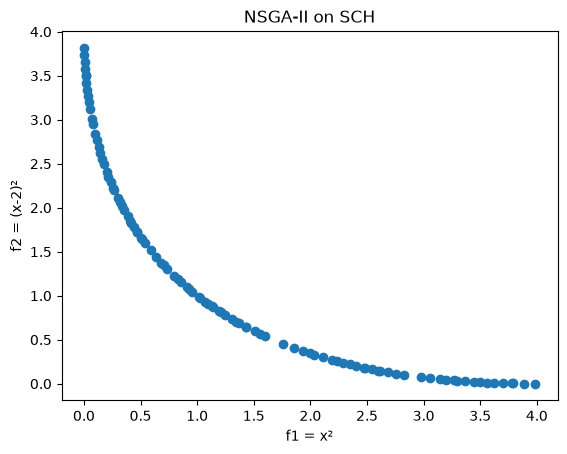

In [ ]:
import matplotlib.pyplot as plt
obj_vals = list(zip(*obj_vals))
plt.scatter(obj_vals[0], obj_vals[1])
plt.xlabel("f1 = x²")
plt.ylabel("f2 = (x-2)²")
plt.title("NSGA-II on SCH")
plt.show()

so why is fronts needed?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Fronts give us a **ranking** of solutions so we know which ones to keep and which to discard.

When we combine parents + offspring, we have more solutions than we need (e.g. 150 instead of 100). We need to pick the best 100 — but "best" is tricky in multiobjective optimization because there's no single best solution.

Fronts solve this by giving us a **priority order**:
- Front 1 solutions are always better than Front 2 (no one in Front 1 is dominated, but Front 2 members are dominated by Front 1)
- Front 2 is better than Front 3, and so on

So we fill our new population front by front — take all of Front 1 first, then Front 2, etc. — until we hit N. Without fronts, we'd have no principled way to decide which solutions to keep and which to throw away when there are multiple conflicting objectives.

Crowding distance then handles the tie-breaking within the last partial front, making sure we keep a diverse spread rather than clustering solutions together.

is this novelity in nsga2

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

No — nondominated sorting was already in the original NSGA (1995). What NSGA-II innovates is:

1. **Fast** nondominated sorting — the original was O(MN³), NSGA-II's version uses the domination count + domination set trick to get O(MN²)
2. **Crowding distance** — replaces the old sharing function method, which needed a user-tuned parameter (σ_share). NSGA-II's approach is parameterless
3. **Elitism** — combining parents + offspring and selecting the best from both, which the original NSGA didn't do

So fronts themselves aren't the novelty — it's making them *fast*, adding *parameterless diversity*, and *preserving good solutions* that makes NSGA-II different.

how does fast nondminated sorting work?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

The key insight is to avoid re-checking every pair for every front. Instead, do **one pass** to precompute two things for each solution `p`:

- **`n_p`** (domination count): how many solutions dominate `p`
- **`S_p`** (domination set): which solutions `p` dominates

This one pass costs O(MN²) — comparing every pair once.

Then peeling off fronts is cheap:

1. **Front 1** = all solutions with `n_p = 0` (nobody dominates them)
2. For each `p` in Front 1, go to its `S_p` and **decrement** `n_q` for each `q` in it. If any `q` reaches `n_q = 0`, it goes to Front 2
3. Repeat for Front 2 → Front 3, etc.

The trick is: instead of re-checking dominance from scratch for each front, we just **count down**. Each solution's `n_p` starts at the total number of solutions that dominate it, and drops to zero exactly when all its dominators have been assigned to earlier fronts.

That's why it's O(MN²) instead of O(MN³) — the expensive pairwise comparisons happen **once**, not once per front.

You already implemented this in your `fast_non_dominated_sort` function — `is_dominated` is `n_p` and `dominates_result` is `S_p`.

I  have one implementation here:
"""NSGA-II: non-dominated sorting and crowding distance for multi-objective optimization."""

import numpy as np


def fast_non_dominated_sort(metrics_list: list[tuple]) -> list[list[int]]:
    """Sort population into Pareto fronts.
    
    Args:
        metrics_list: list of tuples, one per individual. All objectives are MINIMIZED.
    
    Returns:
        List of fronts. Each front is a list of indices into the population.
        fronts[0] = rank-0 (Pareto-optimal), fronts[1] = rank-1, etc.
    """
    n = len(metrics_list)
    domination_count = [0] * n  # how many dominate me
    dominated_set = [[] for _ in range(n)]  # who I dominate
    fronts = [[]]
    
    for i in range(n):
        for j in range(i + 1, n):
            if _dominates(metrics_list[i], metrics_list[j]):
                dominated_set[i].append(j)
                domination_count[j] += 1
            elif _dominates(metrics_list[j], metrics_list[i]):
                dominated_set[j].append(i)
                domination_count[i] += 1
    
    # First front: not dominated by anyone
    for i in range(n):
        if domination_count[i] == 0:
            fronts[0].append(i)
    
    # Build subsequent fronts
    k = 0
    while fronts[k]:
        next_front = []
        for i in fronts[k]:
            for j in dominated_set[i]:
                domination_count[j] -= 1
                if domination_count[j] == 0:
                    next_front.append(j)
        k += 1
        fronts.append(next_front)
    
    # Remove last empty front
    return fronts[:-1]


def crowding_distance(metrics_list: list[tuple], front: list[int]) -> dict[int, float]:
    """Compute crowding distance for individuals in a front.
    
    Returns dict mapping index → crowding distance.
    """
    n = len(front)
    if n <= 2:
        return {idx: float("inf") for idx in front}
    
    n_objectives = len(metrics_list[0])
    distances = {idx: 0.0 for idx in front}
    
    for obj in range(n_objectives):
        # Sort front by this objective
        sorted_front = sorted(front, key=lambda i: metrics_list[i][obj])
        
        # Boundary individuals get infinite distance
        distances[sorted_front[0]] = float("inf")
        distances[sorted_front[-1]] = float("inf")
        
        # Range for normalization
        obj_range = metrics_list[sorted_front[-1]][obj] - metrics_list[sorted_front[0]][obj]
        if obj_range == 0:
            continue
        
        # Interior individuals
        for k in range(1, n - 1):
            distances[sorted_front[k]] += (
                (metrics_list[sorted_front[k + 1]][obj] - metrics_list[sorted_front[k - 1]][obj])
                / obj_range
            )
    
    return distances


def _dominates(a: tuple, b: tuple) -> bool:
    """Does solution a dominate b? (all objectives minimized)"""
    better_in_any = False
    for ai, bi in zip(a, b):
        if ai > bi:
            return False
        if ai < bi:
            better_in_any = True
    return better_in_any

does this looks ok?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

This is a clean, correct implementation. A few things I notice compared to your earlier version:

**`_dominates`** — good improvement over the list comprehension version. The early `return False` when `ai > bi` makes it more efficient since it short-circuits.

**`fast_non_dominated_sort`** — nice optimization: you only compare each pair once (`j` starts at `i+1`) and check both domination directions in one pass. Your earlier version compared all N² pairs (both `i→j` and `j→i`). This cuts the comparisons in half.

**`crowding_distance`** — much cleaner than the pandas version. Two smart details:
- `n <= 2` → all inf (handles edge cases)
- `obj_range == 0` → skip (avoids division by zero when all solutions tie on an objective)

One thing to note: boundary solutions set to `inf` in one objective stay `inf` even when summed with finite values from other objectives, which is correct per the paper.

The only thing missing is that this version takes a single `front` as input to `crowding_distance`, whereas your earlier version handled all fronts at once. You'd call it once per front in the main loop, which is actually cleaner.

What would you like to do next — compare these with your earlier implementations, or move on to testing the full algorithm?

what is currently parent and offsprig? models?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

In NSGA-II, parents and offspring are **solutions** — each one is a set of decision variable values, like `x = [1.5]` for the SCH problem or `x = [0.3, 0.7, ...]` for ZDT1 with 30 variables.

- **Parent**: a solution from the current population
- **Offspring**: a new solution created by crossover (combining two parents) + mutation (random perturbation)

They're not models — they're candidate answers to the optimization problem. Think of it like breeding: parents are the current generation, offspring are their "children" with slightly different traits, and we select the best from both to form the next generation.

In your code, `pop` is the list of parent solutions and `offspring` is what `create_offspring` produces.

I have this code for training: """NSGA-II evolutionary trainer for prescriptor networks (continuous actions)."""

import numpy as np
import pandas as pd

from .prescriptor import Prescriptor
from .nsga2 import fast_non_dominated_sort, crowding_distance
from ..simulator.simulator import summarize_policy


def train(
    context: pd.DataFrame,
    feature_columns: list[str],
    pop_size: int = 100,
    n_generations: int = 100,
    hidden_size: int = 16,
    p_mutation: float = 0.2,
    mutation_factor: float = 0.1,
    config: dict | None = None,
    use_seeds: bool = True,
    verbose: bool = True,
) -> list[Prescriptor]:
    """Run NSGA-II evolution. Returns the final population sorted by rank.
    
    Args:
        context: Feature table with derived features.
        feature_columns: Which columns to feed as input to the neural network.
        pop_size: Population size.
        n_generations: How many generations to evolve.
        hidden_size: Hidden layer size.
        p_mutation: Probability of mutating each weight.
        mutation_factor: Std dev of Gaussian mutation noise.
        config: Simulator config.
        use_seeds: If True, inject baseline-imitating seeds into initial population.
        verbose: Print progress.
    
    Returns:
        List of Prescriptor objects (final population), sorted by Pareto rank.
    """
    from .seeds import create_seed_prescriptors
    
    in_size = len(feature_columns)
    features = context[feature_columns].values.astype(np.float32)
    
    # Normalize features for the network
    feat_mean = features.mean(axis=0)
    feat_std = features.std(axis=0)
    feat_std[feat_std == 0] = 1.0
    features_norm = (features - feat_mean) / feat_std
    
    # Initialize population
    if use_seeds:
        seeds = create_seed_prescriptors(features_norm, context, hidden_size=hidden_size)
        if verbose:
            print(f"Created {len(seeds)} seed prescriptors")
        n_random = max(0, pop_size - len(seeds))
        population = seeds + [Prescriptor(in_size, hidden_size) for _ in range(n_random)]
    else:
        population = [Prescriptor(in_size, hidden_size) for _ in range(pop_size)]
    
    # Evaluate initial population
    _evaluate_population(population, features_norm, context, config)
    
    for gen in range(n_generations):
        # Create offspring
        offspring = _create_offspring(population, pop_size, p_mutation, mutation_factor)
        _evaluate_population(offspring, features_norm, context, config)
        
        # Combine and select
        combined = population + offspring
        population = _select(combined, pop_size)
        
        if verbose and (gen + 1) % 10 == 0:
            front0 = [p for p in population if p.rank == 0]
            avg_metrics = np.mean([p.metrics for p in front0], axis=0)
            print(f"Gen {gen+1:>3d} | Front-0: {len(front0):>3d} | "
                  f"Avg: bio={-avg_metrics[0]:.4f} carbon={-avg_metrics[1]:.4f} "
                  f"cost={avg_metrics[2]:.4f} change={avg_metrics[3]:.1%}")
    
    population.sort(key=lambda p: (p.rank, -getattr(p, "crowding", 0)))
    return population


def _evaluate_population(population, features_norm, context, config):
    """Evaluate fitness of each individual."""
    for p in population:
        target_fractions = p.prescribe(features_norm)
        summary = summarize_policy(context, target_fractions, config)
        
        # NSGA-II minimizes all objectives
        p.metrics = (
            -summary["biodiversity_gain"],
            -summary["carbon_gain"],
            summary["cost"],
            summary["changed_pct"],
        )


def _create_offspring(population, n_offspring, p_mutation, mutation_factor):
    """Create offspring via tournament selection + crossover + mutation."""
    offspring = []
    for _ in range(n_offspring):
        p1 = _tournament_select(population)
        p2 = _tournament_select(population)
        
        # Uniform crossover
        child = p1.copy()
        mask = np.random.rand(child.n_params) < 0.5
        child.params[mask] = p2.params[mask]
        
        # Gaussian mutation
        mut_mask = np.random.rand(child.n_params) < p_mutation
        child.params[mut_mask] += np.random.randn(mut_mask.sum()) * mutation_factor
        
        offspring.append(child)
    return offspring


def _tournament_select(population, k=3):
    """Tournament selection: pick k random, return best rank."""
    candidates = np.random.choice(len(population), size=min(k, len(population)), replace=False)
    best = min(candidates, key=lambda i: (population[i].rank or 999))
    return population[best]


def _select(combined, pop_size):
    """NSGA-II selection: fill next generation by fronts + crowding distance."""
    metrics_list = [p.metrics for p in combined]
    fronts = fast_non_dominated_sort(metrics_list)
    
    next_gen = []
    for rank, front in enumerate(fronts):
        for idx in front:
            combined[idx].rank = rank
        
        if len(next_gen) + len(front) <= pop_size:
            next_gen.extend([combined[idx] for idx in front])
        else:
            distances = crowding_distance(metrics_list, front)
            sorted_front = sorted(front, key=lambda i: -distances[i])
            remaining = pop_size - len(next_gen)
            for idx in sorted_front[:remaining]:
                combined[idx].crowding = distances[idx]
                next_gen.append(combined[idx])
            break
    
    return next_gen
 does this look correct?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

The overall structure is solid — it follows the NSGA-II loop correctly. But I see a few issues:

**1. Tournament selection ignores crowding distance**

`_tournament_select` only compares by rank:
```python
best = min(candidates, key=lambda i: (population[i].rank or 999))
```

The paper says ties in rank should be broken by **higher crowding distance**. It should be something like:
```python
best = min(candidates, key=lambda i: (population[i].rank or 999, -(population[i].crowding or 0)))
```

**2. Initial population isn't ranked before generation 1**

After `_evaluate_population(population, ...)` on the initial population, ranks are never computed. So in the first generation, `_tournament_select` sees `rank = None` for everyone (falls back to 999). You need to run `_select` or at least `fast_non_dominated_sort` + assign ranks after the initial evaluation.

**3. Crowding distance only computed for the partial front**

In `_select`, `crowding` is only set for individuals in the last partial front. Individuals in fully-included fronts never get their crowding distance computed, so tournament selection can't use it for tie-breaking.

Want to fix these, or would you like to discuss any of them first?

## ALternatives

what are alternatvies to nsga2?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

There are several other multiobjective evolutionary algorithms:

- **SPEA2** — improved version of SPEA. Uses a strength-based fitness assignment (how many solutions you dominate) plus a nearest-neighbor density estimate for diversity. Similar elitist approach but different selection mechanism.

- **PAES** — simple (1+1) evolution strategy with an archive of nondominated solutions. Uses a grid-based crowding method. Simpler but less effective on complex problems.

- **MOEA/D** — decomposes the multiobjective problem into many single-objective subproblems, each optimized simultaneously with neighbor information. Works well on problems with many objectives (NSGA-II struggles past 3-4 objectives).

- **SMS-EMOA** — uses hypervolume contribution as the selection criterion instead of crowding distance. Computationally expensive but very effective for diversity.

- **R-NSGA-II** — a variant that lets you specify reference points on the Pareto front, focusing the search on regions the user cares about.

The paper itself compares NSGA-II against SPEA and PAES. For problems with many objectives (more than 3), MOEA/D is generally preferred.

Would you like to explore any of these in more detail?

why is NSGA2 used? it looks rather simple algorithm

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Its simplicity is actually a big reason it's so popular! A few key factors:

- **Effective** — it works well on a wide range of problems without much tuning, as the paper's results showed
- **Fast** — O(MN²) sorting made it practical for real-sized populations compared to the original NSGA's O(MN³)
- **Parameterless diversity** — crowding distance doesn't need a sharing parameter (σ_share), so users don't have to guess a good value
- **Elitism built in** — combining parents + offspring prevents losing good solutions
- **Easy to implement** — as you've seen, the core is just a few hundred lines of code

In practice, "simple and works reliably" often beats "complex and needs careful tuning." Many real-world engineering and scientific applications just need good Pareto front solutions without a deep optimization background, and NSGA-II delivers that.

## Reminder

so NSGAII works like so:
- generate populaitions (like make neural network) 
- evalute them against bojctive function
- sort into fronts and compute crowding distances inside fronts
- create offspring by using corssover and mutation (liek changing wieghts), select ones where crowding distance is higher?
- combine parents and offspring
- sort combined population into fronts
- ??

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Almost right! A couple of clarifications:

- When creating offspring, tournament selection picks parents based on **rank first**, then **crowding distance** as a tiebreaker (not crowding distance alone)
- The missing last step: **fill the new population of size N** by taking whole fronts in order (Front 1, Front 2, ...) until the next front won't fully fit. For that last partial front, sort by crowding distance descending and take only the top few needed to reach N.

Then that new population becomes the parents for the next generation, and the loop repeats.

So the full cycle is: evaluate → sort → create offspring → combine → sort combined → fill N → repeat.

rank is front?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Yes — rank is just the front number. If you're in Front 1, your rank is 1. Front 2, rank is 2. And so on. Lower rank = better.

novelty is in the fact that it finds solution fast and cosniders multiple ciretiras?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Not quite — considering multiple criteria was already well established before NSGA-II (the original NSGA, MOGA, NPGA all did that). The novelty of NSGA-II is specifically:

1. **Fast** nondominated sorting (O(MN²) vs O(MN³)) — the domination count trick
2. **Parameterless** diversity via crowding distance (no σ_share to tune)
3. **Elitism** by combining parent + offspring populations

These three improvements together made it faster, simpler to configure, and better at preserving good solutions — which is why it became so widely adopted.